# Afluencia del Metro

### Analis de Series de Tiempo | ESCOM
#### Profesor: Guadalupe Ana Gabriela Martínez Hernández


#### Alumnos:
+ Pacheco Molina Miguel Alejandro
+ Soria Martinez Jesús Armando



# Sección Inicial (Configuración)

In [ ]:
!pip install arch

In [ ]:
#from google.colab import files
#uploaded = files.upload()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

import statsmodels.api as sm
import statsmodels.tsa.api as tsa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### __Carga del dataset__

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/data-2025-10-03.csv', encoding='utf-8')

#### __Visualización__

In [ ]:
display(df.head())
display(df.info())
display(df.describe())

,fecha,anio,mes,linea,estacion,afluencia,temporal_fecha,..anio_fecha
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,2010-01,2010
1,2010-01-01,2010,Enero,Linea 1,Isabel la CatÃ³lica,6487,2010-01,2010
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,2010-01,2010
3,2010-01-01,2010,Enero,Linea 1,Pino SuÃ¡rez,8679,2010-01,2010
4,2010-01-01,2010,Enero,Linea 1,GÃ³mez FarÃ­as,19499,2010-01,2010


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115790 entries, 0 to 1115789
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   fecha           1115790 non-null  object
 1   anio            1115790 non-null  int64 
 2   mes             1115790 non-null  object
 3   linea           1115790 non-null  object
 4   estacion        1115790 non-null  object
 5   afluencia       1115790 non-null  int64 
 6   temporal_fecha  1115790 non-null  object
 7   ..anio_fecha    1115790 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 68.1+ MB


None

,anio,afluencia,..anio_fecha
count,1.115790e+06,1.115790e+06,1.115790e+06
mean,2.017340e+03,1.970792e+04,2.017340e+03
std,4.525220e+00,1.948871e+04,4.525220e+00
min,2.010000e+03,0.000000e+00,2.010000e+03
25%,2.013000e+03,7.432000e+03,2.013000e+03
50%,2.017000e+03,1.445300e+04,2.017000e+03
75%,2.021000e+03,2.552600e+04,2.021000e+03
max,2.025000e+03,2.630560e+05,2.025000e+03


# Reporte 1°

En este reporte se realiza la exploración de la serie, se realizó el preprocesamiento y Análisis de Componentes de la serie original.

#### __Filtrado de Columnas__

In [ ]:
#df = df.drop(columns=['estacion', 'tipo_pago'])
df = df.drop(columns=['estacion'])
df = df[df['anio']>2020]
df.head(3)

,fecha,anio,mes,linea,afluencia,temporal_fecha,..anio_fecha
783510,2021-01-01,2021,Enero,LÃ­nea 1,2963,2021-01,2021
783511,2021-01-01,2021,Enero,LÃ­nea 1,2676,2021-01,2021
783512,2021-01-01,2021,Enero,LÃ­nea 1,8740,2021-01,2021


#### __Tratamiento Columna "Linea"__

In [ ]:
print(df['linea'].unique())

['LÃ\xadnea 1' 'LÃ\xadnea 12' 'LÃ\xadnea 2' 'LÃ\xadnea 3' 'LÃ\xadnea 4'
 'LÃ\xadnea 5' 'LÃ\xadnea 6' 'LÃ\xadnea 7' 'LÃ\xadnea 8' 'LÃ\xadnea 9'
 'LÃ\xadnea A' 'LÃ\xadnea B' 'Linea 1' 'Linea 12' 'Linea 2' 'Linea 3'
 'Linea 4' 'Linea 5' 'Linea 6' 'Linea 7' 'Linea 8' 'Linea 9' 'Linea A'
 'Linea B']


+ __Hay un problema de codificación__

In [ ]:
df['linea'] = df['linea'].apply(lambda x: x.encode('latin1').decode('utf-8') if isinstance(x, str) else x)
df['linea'] = df['linea'].str.replace('Línea', 'Linea')  # quitamos los acentos
df['linea'] = df['linea'].str.strip().str.title()
display(df.head(10))

,fecha,anio,mes,linea,afluencia,temporal_fecha,..anio_fecha
783510,2021-01-01,2021,Enero,Linea 1,2963,2021-01,2021
783511,2021-01-01,2021,Enero,Linea 1,2676,2021-01,2021
783512,2021-01-01,2021,Enero,Linea 1,8740,2021-01,2021
783513,2021-01-01,2021,Enero,Linea 1,2732,2021-01,2021
783514,2021-01-01,2021,Enero,Linea 1,7584,2021-01,2021
783515,2021-01-01,2021,Enero,Linea 1,2509,2021-01,2021
783516,2021-01-01,2021,Enero,Linea 1,23186,2021-01,2021
783517,2021-01-01,2021,Enero,Linea 1,7312,2021-01,2021
783518,2021-01-01,2021,Enero,Linea 1,2873,2021-01,2021
783519,2021-01-01,2021,Enero,Linea 1,1057,2021-01,2021


In [ ]:
print(df['linea'].unique())

['Linea 1' 'Linea 12' 'Linea 2' 'Linea 3' 'Linea 4' 'Linea 5' 'Linea 6'
 'Linea 7' 'Linea 8' 'Linea 9' 'Linea A' 'Linea B']


### __Serie Mensual__

### __Afluencia total del metro por Mes__

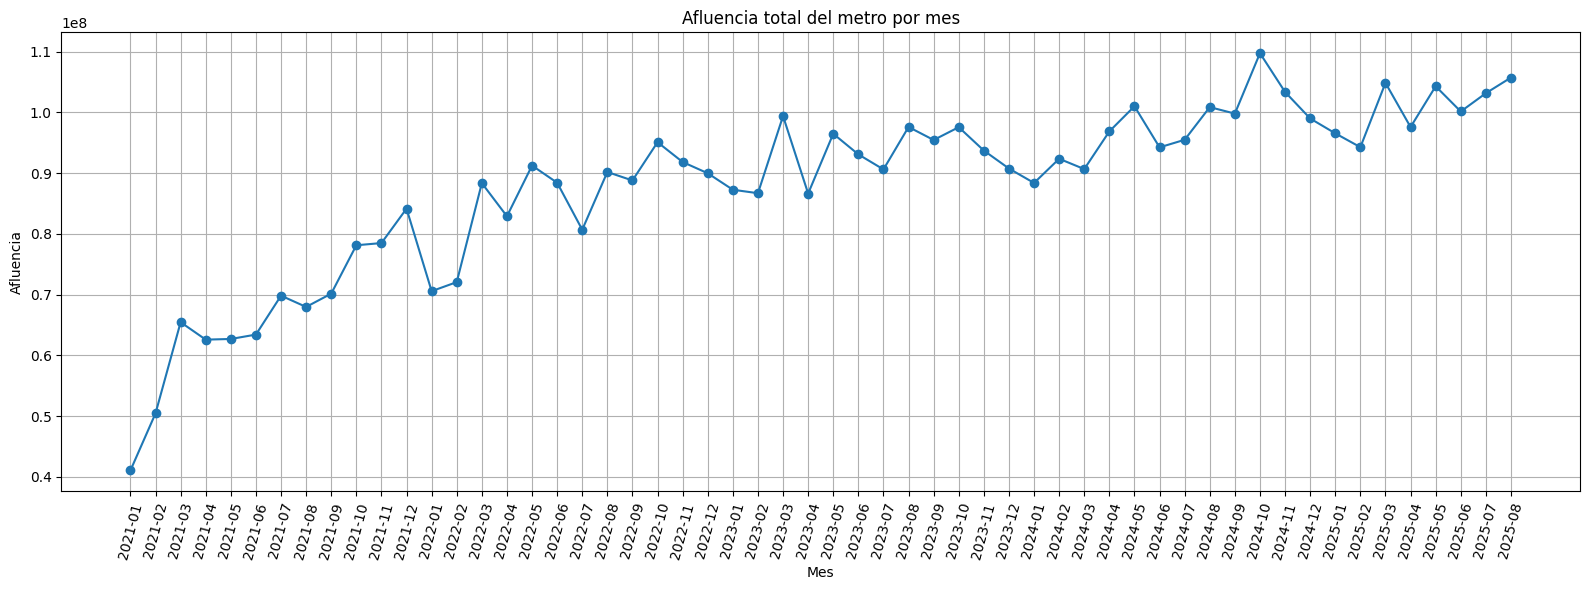

In [ ]:
# Agrupacion por mes
afluencia_mensual = df.groupby('temporal_fecha')['afluencia'].sum().reset_index()

# Graficar
plt.figure(figsize=(16,6))
plt.plot(afluencia_mensual['temporal_fecha'], afluencia_mensual['afluencia'], marker='o')
plt.xticks(rotation=75)
plt.title('Afluencia total del metro por mes')
plt.xlabel('Mes')
plt.ylabel('Afluencia')
plt.grid(True)
plt.tight_layout()
plt.show()

### __Afluencia total del Metro por dia__

In [ ]:
import matplotlib.dates as mdates
import plotly.express as px
afluencia_diaria = df.groupby(['fecha','anio'])['afluencia'].sum().reset_index()

fig = px.line(          # Grafico de Lineas
    afluencia_diaria,
    x='fecha',
    y='afluencia',
    title='Afluencia total del metro por día',
    labels={'fecha': 'Día', 'afluencia': 'Afluencia'},
    hover_data={'anio': True}  # muestra el año al pasar el mouse
)

# Agregar filtro por año (dropdown)
fig.update_layout(                     # Controles interactivos
    updatemenus=[
        dict(
            buttons=list([
                dict(label=str(año),
                     method="update", #Actualiza la grafica al seleccionar
                     args=[{"x": [afluencia_diaria[afluencia_diaria['anio']==año]['fecha']],
                            "y": [afluencia_diaria[afluencia_diaria['anio']==año]['afluencia']]}])
                for año in sorted(afluencia_diaria['anio'].unique())
            ]),
            direction="down",
        )
    ]
)

fig.show()

### **Analisis de Componentes**

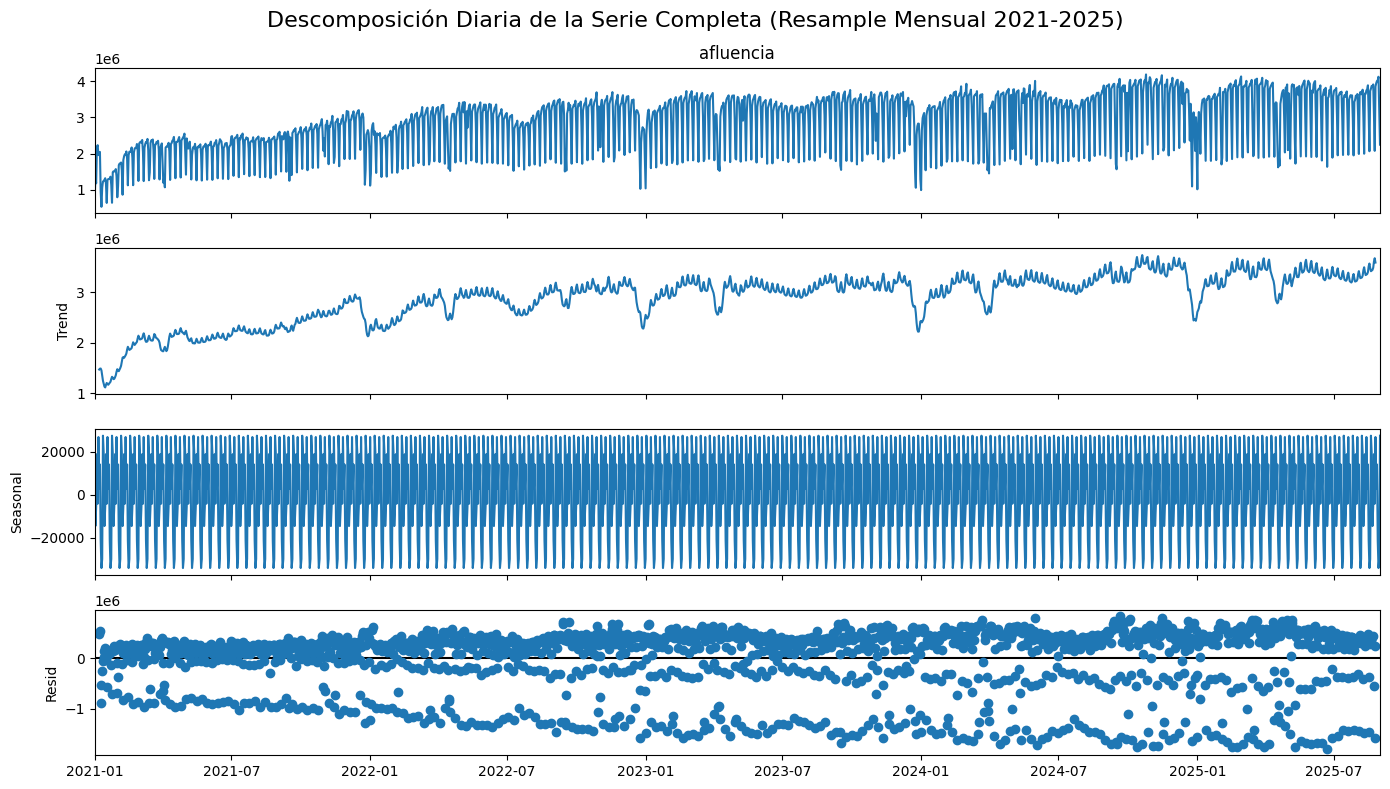

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --- PASO 1: Volver a crear el DataFrame original (Para evitar el error) ---
# Asegúrate de que 'df' (tu tabla original limpia) esté cargada en memoria
afluencia_diaria = df.groupby(['fecha','anio'])['afluencia'].sum().reset_index()

# --- PASO 2: Formato de Fecha e Índice ---
# Ahora sí, convertimos y asignamos el índice
afluencia_diaria['fecha'] = pd.to_datetime(afluencia_diaria['fecha'])
afluencia_diaria.set_index('fecha', inplace=True)

# --- PASO 3: Seleccionar y Resamplear ---
ts_diaria = afluencia_diaria['afluencia']

# Calculamos el promedio mensual para la gráfica
ts_mensual = ts_diaria.resample('ME').mean()


# Descomposición
result = seasonal_decompose(ts_diaria.dropna(), model='additive', period=12)

# Grafica
fig = result.plot()
fig.set_size_inches(14, 8)
plt.suptitle('Descomposición Diaria de la Serie Completa (Resample Mensual 2021-2025)', fontsize=16)
plt.tight_layout()
plt.show()

### __Prueba ADF__

In [ ]:
result_adf = adfuller(ts_diaria.dropna())

print("Resultados ADF para la Serie Completa (2021-2025)")
print(f"Estadístico ADF: {result_adf[0]:.4f}")
print(f"Valor p (p-value): {result_adf[1]:.4f}")

# Interpretación automática
if result_adf[1] < 0.05:
    print("La serie es estacionaria (se rechaza H0).")
else:
    print("La serie NO es estacionaria (no se rechaza H0).")

Resultados ADF para la Serie Completa (2021-2025)
Estadístico ADF: -3.5858
Valor p (p-value): 0.0060
La serie es estacionaria (se rechaza H0).


### __Análisis de Autocorrelación__

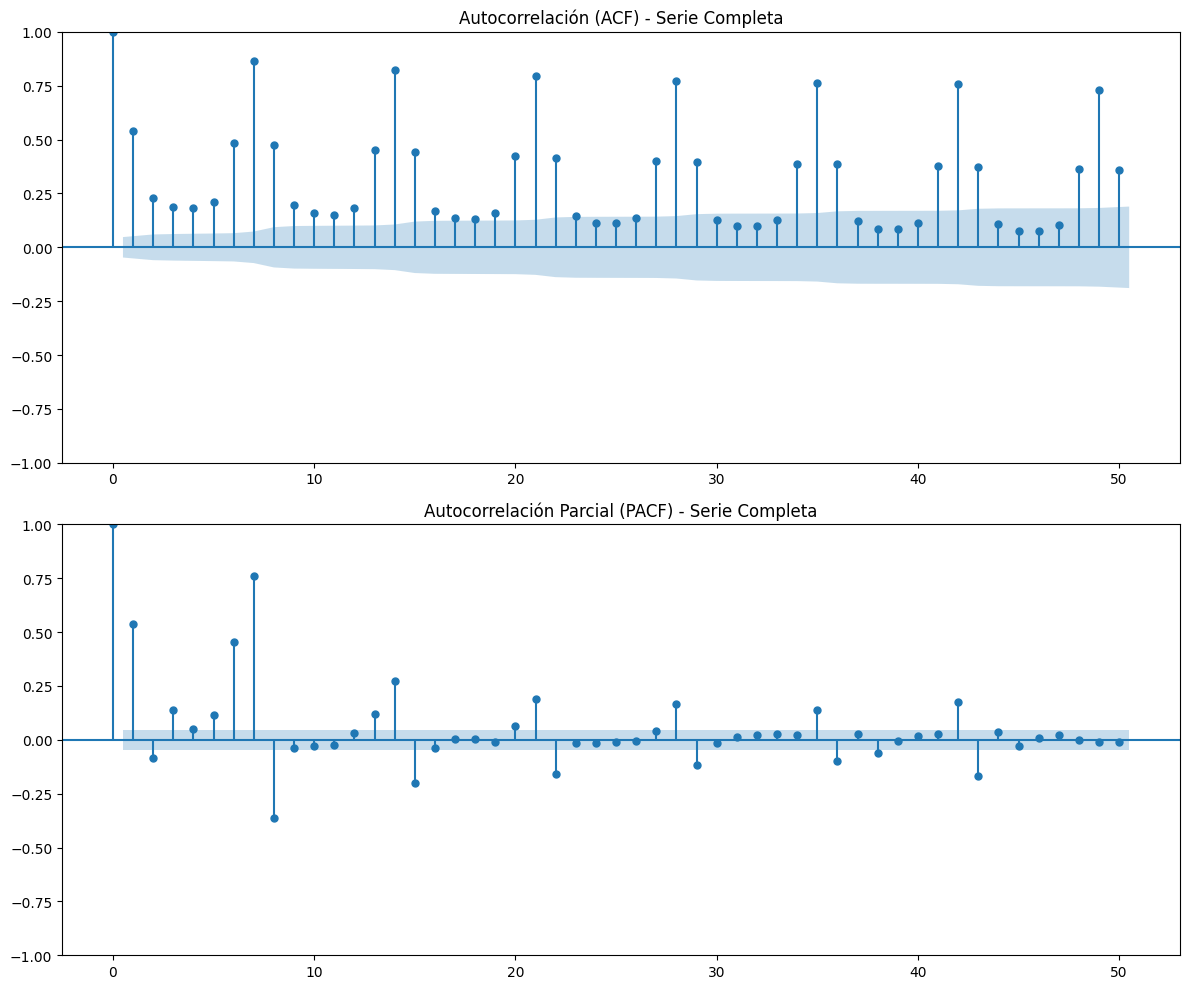

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ACF - Muestra la persistencia de la memoria (Tendencia)
# lags=50 para ver casi dos meses de historia
plot_acf(ts_diaria.dropna(), lags=50, ax=axes[0], title='Autocorrelación (ACF) - Serie Completa')

# PACF - Muestra la correlación directa
plot_pacf(ts_diaria.dropna(), lags=50, ax=axes[1], title='Autocorrelación Parcial (PACF) - Serie Completa')

plt.tight_layout()
plt.show()

__Interpretación de Autocorrelación (Serie Completa 2021-2025)__


1. __ACF:__ Se observa un comportamiento de decaimiento extremadamente lento en la Función de Autocorrelación. Las correlaciones significativas se mantienen altas incluso después de 50 rezagos, esto indica tendenci fuerte, la media de la serie cambia significativamente a lo largo de los años.

2. Estacionalidad Semanal Marcada: Tanto en la ACF como en la PACF, se observan picos prominentes y repetitivos cada 7 rezagos (7, 14, 21, 28...). Esto confirma la fuerte estacionalidad semanal del Metro.

__Conclusión Final sobre la Serie Original:__ La combinación de una tendencia de largo plazo (decaimiento lento en ACF) y un cambio estructural en los años 2021-2022 justifica la decisión de no modelar la serie completa. Para evitar sesgos por la tendencia histórica, es metodológicamente preferible aislar el segmento 2023, donde la serie presenta un comportamiento más estable y homogéneo.

# Reporte 2°

Para este Reporte 2, se modificó la granularidad temporal de las mediciones: en lugar de utilizar registros diarios de afluencia del Metro de la Ciudad de México, ahora se trabaja con valores semanales. Este cambio permite reducir la alta estacionalidad observada en la serie diaria (especialmente los descensos de afluencia en domingos) y facilita un análisis más estable.

## Se convierte la variable "fecha" a indice y solo nos quedamos con la variable de interes "afluencia".

In [ ]:
# Convierte la columna 'fecha' a tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Copia df
df_total = df.copy()

# Filtra solo 2023
df_total = df_total[df_total['anio'] == 2023]

# Agrupa por fecha y suma la afluencia total para el año 2023
df_total = df_total.groupby('fecha')['afluencia'].sum().reset_index()

# Establece 'fecha' como índice
series = df_total.set_index('fecha')


# Resample para obtener la afluencia semanal sumando los valores
series = series.resample('W').sum()                                 #   'W'       'W-MON'


In [ ]:
series

,afluencia
fecha,
2023-01-01,1035285
2023-01-08,18735884
2023-01-15,19560914
2023-01-22,20515381
2023-01-29,20801719
2023-02-05,21541590
2023-02-12,20226027
2023-02-19,22192659
2023-02-26,22476981


In [ ]:
len(series)

53

Visualización de la serie

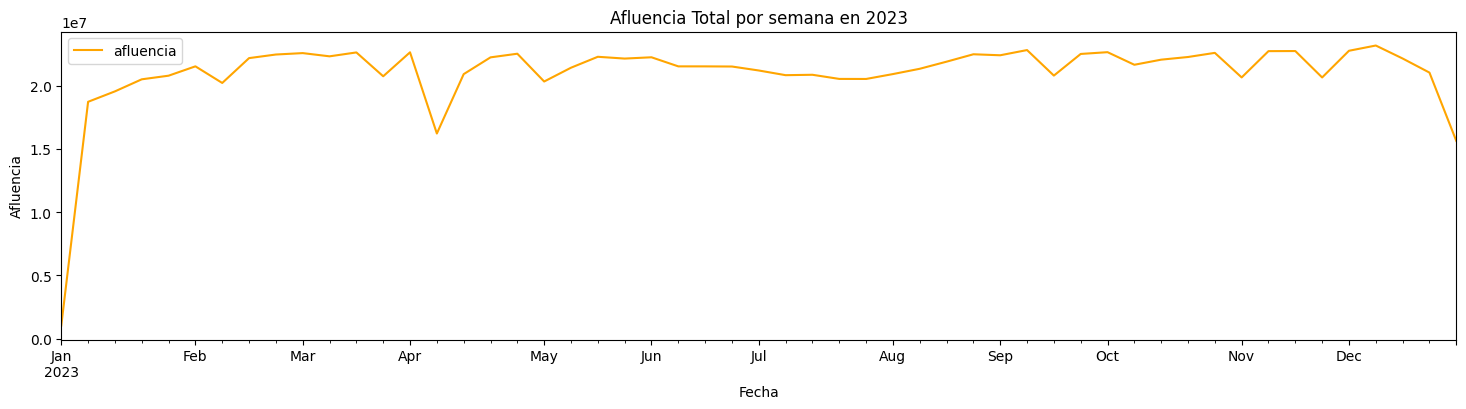

In [ ]:
# Visualización

# Grafica la serie
series.plot(figsize=(18, 4), color='orange', title="Afluencia Total por semana en 2023")

# Añade etiquetas y leyenda
plt.xlabel('Fecha')
plt.ylabel('Afluencia')
plt.legend()

# Muestra el gráfico
plt.show()


## 1. Análisis Exploratorio de Componentes

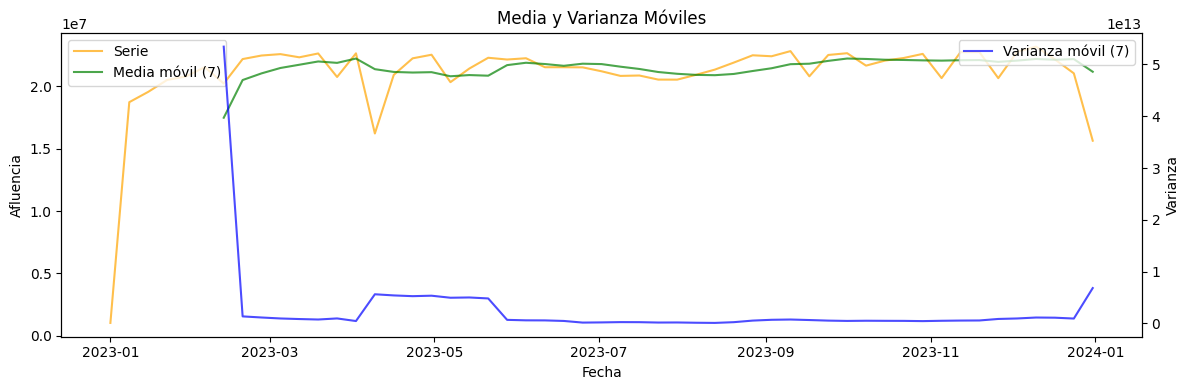

In [ ]:
"""
Inspeccionar la media, varianza y comportamiento gráfico inicial.
"""

# Media y varianza móviles
rolling_mean = series.rolling(window=7).mean() # Calcular el promedio de un conjunto de datos dentro de una ventana temporal
rolling_var = series.rolling(window=7).var()   # Calcula la variabilidad o dispersión de los datos dentro de una ventana móvil de tamaño k

fig, ax1 = plt.subplots(figsize=(12, 4))

# Grafica la serie original y la media móvil en el primer eje Y
ax1.plot(series, color='orange', label="Serie", alpha=0.7)
ax1.plot(rolling_mean, color="green", label="Media móvil (7)", alpha=0.7)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Afluencia')
ax1.set_title("Media y Varianza Móviles")

# Se utiliza el método twinx() para crear un segundo eje Y en el gráfico, que permite mostrar la varianza móvil con una escala diferente sin que distorsione la visualización de la serie original y la media móvil.
# Crear un segundo eje Y para la varianza
ax2 = ax1.twinx()
ax2.plot(rolling_var, color="blue", label="Varianza móvil (7)", alpha=0.7)
ax2.set_ylabel('Varianza')

# Añade leyendas
ax1.legend(loc='upper left')  # para la serie y media móvil
ax2.legend(loc='upper right') # para la varianza

plt.tight_layout()
plt.show()


__Interpretacion:__

La serie original (naranja) Corresponde a la afluencia semanal observada.
Después de cambiar la frecuencia diaria a semanal desaparecieron los patrones repetitivos (caídas en la afluencia de los domingos), por lo que se ya no hay una estacionalidad semanal tan marcada

La media móvil (verde) de 7 días suaviza las oscilaciones semanales y permite ver la tendencia general a lo largo del año.

La varianza móvil (azul) Representa la volatilidad o dispersión de la afluencia dentro de ventanas de 7 días.


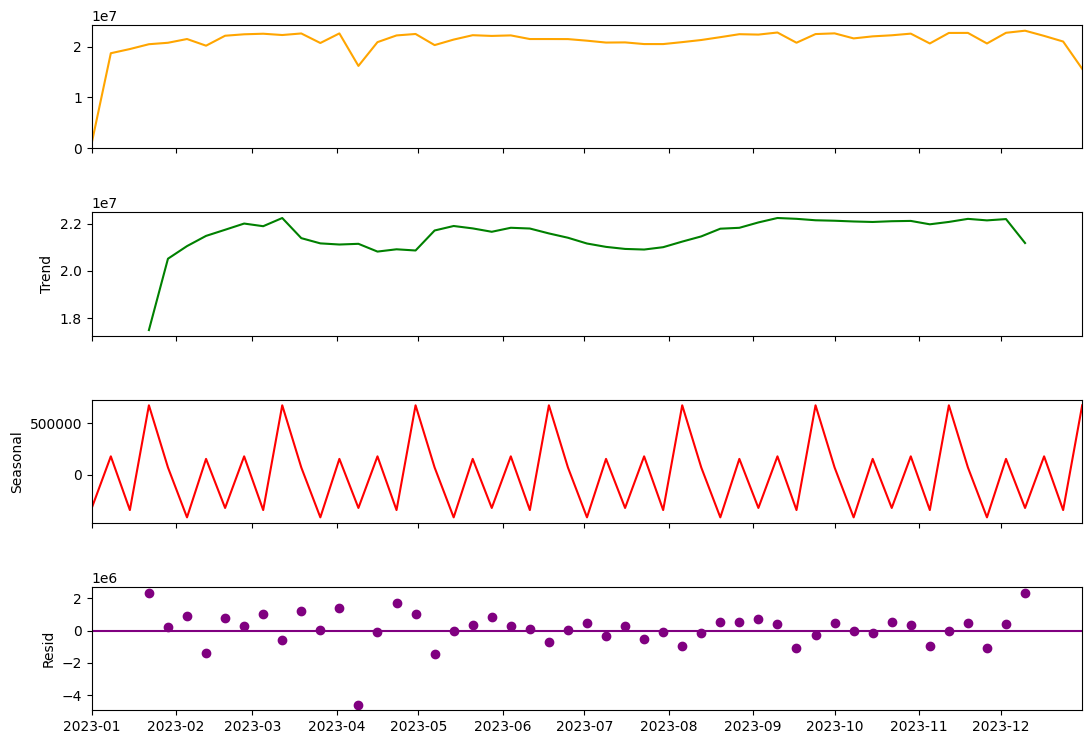

In [ ]:
# Descomposición en componentes
decomp = seasonal_decompose(series, model='additive', period=7)

fig = decomp.plot()
fig.set_size_inches(12, 8)

# Cambiar colores de los subplots
colors = ['orange', 'green', 'red', 'purple'] # Define los colores deseados
for i, ax in enumerate(fig.axes):
    for line in ax.get_lines():
        line.set_color(colors[i % len(colors)]) # Asigna un color a cada línea

plt.show()

Se cambio el periodo= 30, a periodo=7 porque los datos ahora son semanales y se podría esperar que los patrones estacionales se repitan semanalmente.


## 2. Pruebas de Correlación

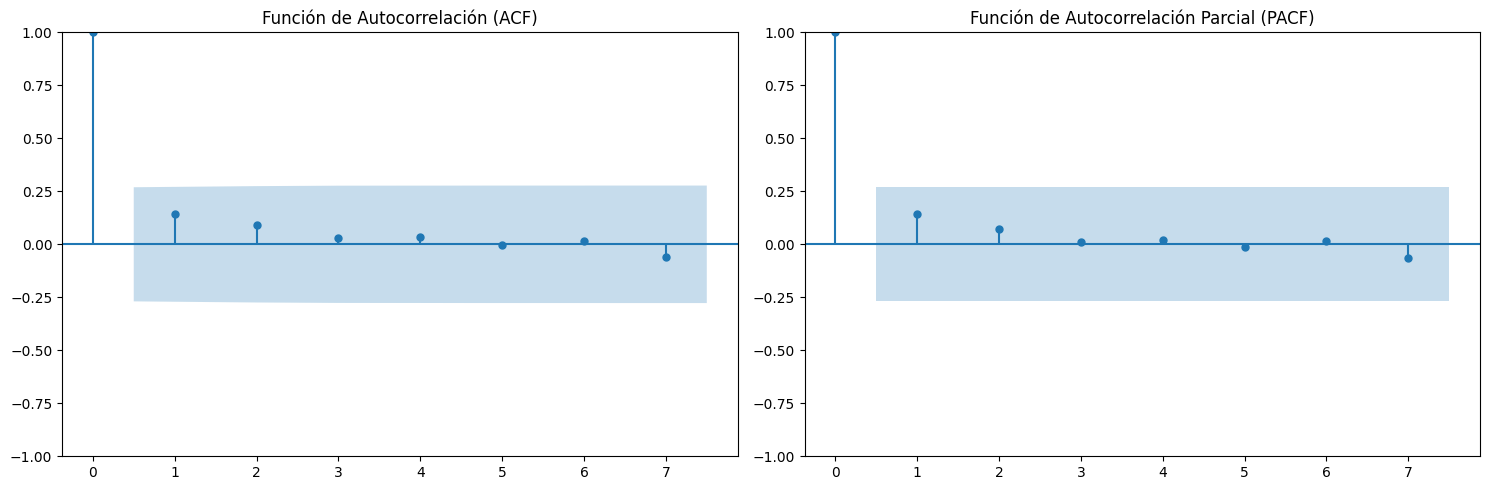

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(series, lags=7, ax=axes[0])
axes[0].set_title('Función de Autocorrelación (ACF)')

plot_pacf(series, lags=7, ax=axes[1])
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()

 - ACF

Solo el lag 0 está fuera de la banda de confianza, todos los demás lags (1 al 7) se encuentran dentro del intervalo azul, es decir, no son significativos.

Esto implica que no hay una correlación significativa entre una semana y las semanas anteriores, la dependencia temporal se redujo notablemente al pasar de datos diarios a semanales

 - PACF

Confirma que no hay una correlación directa significativa con los valores de semanas pasadas, esto indica ausencia de dependencia autoregresiva. Por tanto, la serie semanal podría comportarse como un ruido blanco.

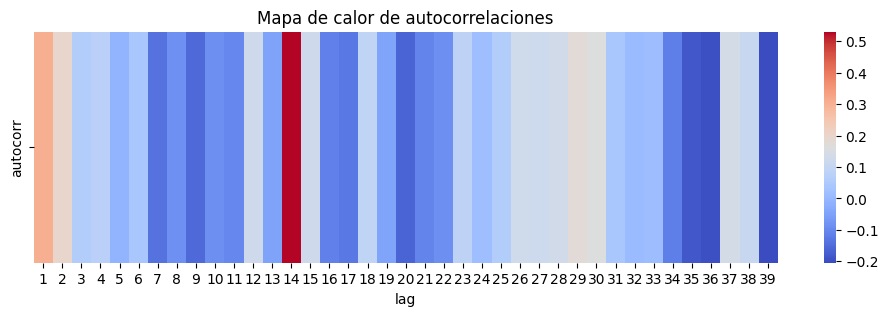

In [ ]:
# Cálculo de autocorrelaciones hasta lag 40
autocorrs = [series['afluencia'].autocorr(lag=i) for i in range(1, 40)]  # Accede a la columna 'afluencia'
df_autocorr = pd.DataFrame({"lag": range(1, 40), "autocorr": autocorrs})

# Graficar el mapa de calor
plt.figure(figsize=(12, 3))
sns.heatmap(df_autocorr.set_index("lag").T, annot=False, cmap="coolwarm", cbar=True)
plt.title("Mapa de calor de autocorrelaciones")
plt.show()


Ljung-Box (autocorrelación)
- **Hipótesis**:
  - H0: No hay autocorrelación hasta el lag m
  - H1: Hay autocorrelación
- **Regla**: si p-value < 0.05 → Rechazamos H0 → Hay autocorrelación

In [ ]:
# Test Ljung-Box
"""
Hipótesis:
H0: No existe autocorrelación en la serie (es ruido blanco)
H1: Existe autocorrelación
Si p < 0.05 → Rechazamos H0
"""
ljung = acorr_ljungbox(series, lags=[10, 20, 30], return_df=True)
print("--- Ljung-Box Test ---")
print(ljung)

--- Ljung-Box Test ---
     lb_stat  lb_pvalue
10  2.391945   0.992359
20  6.707494   0.997540
30  7.572724   0.999989


**Interpretación de resultados: No Rechazamos H0 (No Existe autocorrelación)**

En todos los casos, al ahora trabajar con intervales semanales, los p-values ya no son bajos, en ningun nivel de significancia usual (1%, 5%, 10%).

1. Para lag = 10:
*   lb_stat = 2.39
*   p-value = 0.992359 (ya no es bajo)

2. Para lag = 20:

*   lb_stat = 6.71
*   p-value = 0.997540 (ya no es bajo)


3. Para lag = 30:

*   lb_stat = 7.57
*   p-value = 0.999989 (ya no es bajo)


Tras transformar la serie de afluencia del Metro CDMX de frecuencia diaria a semanal, la serie perdio autocorrelacion, esto implica que la serie se comporta como ruido blanco o como un proceso muy cercano a independiente, lo cual concuerda con las gráficas ACF y PACF que ya analizamos (sin picos significativos).

## 3. Pruebas de Estacionariedad

Prueba ADF sobre residuos AR(1)

- **Hipótesis**:
  - H0: La serie tiene raíz unitaria (no estacionaria)
  - H1: La serie es estacionaria
- **Regla**: si p-value < 0.05 → Rechazamos H0 → serie estacionaria

- **Interpretabilidad:**
  - Valor ADF más negativo = Mejor (más evidencia de estacionariedad)
  - Valores típicos ADF: Entre -6 y 0
  - Regla práctica: Si ADF < -3, probablemente estacionaria

In [ ]:
# Test de estacionariedad (ADF)
"""
Augmented Dickey-Fuller Test (ADF)
Hipótesis:
H0: La serie tiene raíz unitaria → No estacionaria
H1: La serie es estacionaria
Si p < 0.05 → Rechazamos H0 → La serie es estacionaria
"""
adf_result = adfuller(series)
print("\n--- Augmented Dickey-Fuller Test ---")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
for key, value in adf_result[4].items():
    print(f"Critical Value {key}: {value:.4f}")
print("Decisión:", "Estacionaria" if adf_result[1] < 0.05 else "No estacionaria")


--- Augmented Dickey-Fuller Test ---
ADF Statistic: -13.4131
p-value: 0.0000
Critical Value 1%: -3.5629
Critical Value 5%: -2.9190
Critical Value 10%: -2.5974
Decisión: Estacionaria


**Interpretación de resultados**:

ADF Statistic = -13.4131
Este valor se compara con los valores críticos:

* A 1%: -3.5629

* A 5%: -2.9190

* A 10%: -2.5974

Como -13.4131 < -3.5629 (valor crítico al 1%), el estadístico cae en la región de rechazo incluso con un nivel de significancia muy estricto.

Rechazamos H0 con alta confianza (α = 0.01, 0.05 o 0.10).
Esto significa que la probabilidad de que la serie tenga raíz unitaria es prácticamente nula. Por lo tanto, la serie de afluencia semanal del Metro CDMX 2023 es estacionaria.

## 4. Ajuste del Modelo

In [ ]:
y = series['afluencia']

# --- Ajustar AR(1) para obtener residuos ---
model_1 = ARIMA(series['afluencia'], order=(1,0,1))   # (1,0,1)
result = model_1.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:              afluencia   No. Observations:                   53
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -909.605
Date:                Sun, 14 Dec 2025   AIC                           1827.210
Time:                        23:27:33   BIC                           1835.092
Sample:                    01-01-2023   HQIC                          1830.241
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.104e+07   6.79e-10    3.1e+16      0.000     2.1e+07     2.1e+07
ar.L1          0.9050      0.009     98.554      0.000       0.887       0.923
ma.L1         -0.2103      0.033     -6.447      0.0

__Interpretacion__

__const: 2.104e+07__

* Es la media o nivel promedio semanal de la afluencia.

* Representa aproximadamente 21.04 millones de pasajeros por semana, un valor altamente significativo (p < 0.001).

__ar.L1: 0.9050__

* Indica que el valor actual de la afluencia depende en un 90.5% del valor de la semana anterior, mostrando una fuerte inercia temporal.

* Aunque las autocorrelaciones no eran significativas globalmente, el modelo encuentra una relación directa alta entre semanas consecutivas


__ma.L1 = -0.2103__

* Coeficiente de media móvil del primer rezago.

* Valor negativo moderado, indica que parte del ruido en la serie actual se corrige utilizando los errores de predicción de la semana previa.


__sigma2: 2.084e+12__

* Varianza de los errores/residuos.

* El modelo logra capturar la tendencia principal, pero podrían existir fluctuaciones externas (por ejemplo, vacaciones, cierres de estaciones, eventos públicos) que incrementan la varianza.

In [ ]:
# --- ANÁLISIS DE SIMULACIÓN ---
print("ANÁLISIS DE SIMULACIÓN:")

# Usamos directamente el coeficiente AR(1) del modelo ajustado
ar_coef = result.params['ar.L1']
const = result.params['const']

print(f"Modelo ajustado AR(1): y(t) = {const:.0f} + {ar_coef:.4f} * y(t-1) + u(t)")
print(f"Interpretación: El valor de hoy depende ~{ar_coef*100:.1f}% del valor de ayer.")
print(f"Residuos: varianza = {result.params['sigma2']:.2e}, representan la dispersión no explicada por el modelo.")


ANÁLISIS DE SIMULACIÓN:
Modelo ajustado AR(1): y(t) = 21043383 + 0.9050 * y(t-1) + u(t)
Interpretación: El valor de hoy depende ~90.5% del valor de ayer.
Residuos: varianza = 2.08e+12, representan la dispersión no explicada por el modelo.


__Interpretabilidad ARMA(1) – Serie de afluencia semanal Metro CDMX 2023__

El modelo AR(1) refleja que la afluencia diaria al Metro presenta alta persistencia temporal, con un 90.5 % de dependencia respecto al día anterior.

Sin embargo, la alta varianza residual (2.08×10¹²) sugiere que el modelo no logra capturar completamente la variabilidad del sistema.

In [ ]:
# --- Ajustar AR(1) para obtener residuos ---
model_opc = ARIMA(y, order=(1,0,1))   # (1,0,1)
result_opc = model_opc.fit()
print(result_opc.summary())

                               SARIMAX Results                                
Dep. Variable:              afluencia   No. Observations:                   53
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -909.605
Date:                Sun, 14 Dec 2025   AIC                           1827.210
Time:                        23:27:35   BIC                           1835.092
Sample:                    01-01-2023   HQIC                          1830.241
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.104e+07   6.79e-10    3.1e+16      0.000     2.1e+07     2.1e+07
ar.L1          0.9050      0.009     98.554      0.000       0.887       0.923
ma.L1         -0.2103      0.033     -6.447      0.0

**Interpretabilidad ARIMA(1,0,1) == ARMA(1,1)**

* __Ljung–Box (Q = 4.08, p = 0.04):__
Existe ligera evidencia de autocorrelación en los residuos.
Esto indica que el modelo no elimina completamente la dependencia temporal, aunque la magnitud del efecto es pequeña.

* __Jarque–Bera (JB = 317.22, p = 0.00):__
Los residuos no son normales, con asimetría positiva (Skew = 1.01) y alta curtosis (14.81).
Esto significa que hay algunas semanas con valores atípicos muy altos (picos de afluencia, como en vacaciones o eventos masivos).

El modelo ARIMA(1,0,1) describe adecuadamente la tendencia y persistencia semanal de la afluencia al Metro, mostrando una fuerte dependencia entre semanas consecutivas.
Sin embargo:

Persiste cierta autocorrelación en los residuos, lo que sugiere que aún hay información temporal no capturada.

Los residuos no son normales y muestran heterocedasticidad.



El modelo ARIMA(1,0,1) para la afluencia semanal del Metro CDMX 2023 muestra que la cantidad de pasajeros presenta una gran estabilidad de una semana a otra (90.5% de dependencia). Las fluctuaciones semanales tienden a corregirse parcialmente con un efecto de media móvil del 21%. Aunque el modelo explica bien el comportamiento promedio, los residuos presentan variaciones no constantes y valores extremos, lo que indica la presencia de semanas atípicas o efectos externos que el modelo no logra capturar completamente.

## 5. Diagnóstico de Residuos

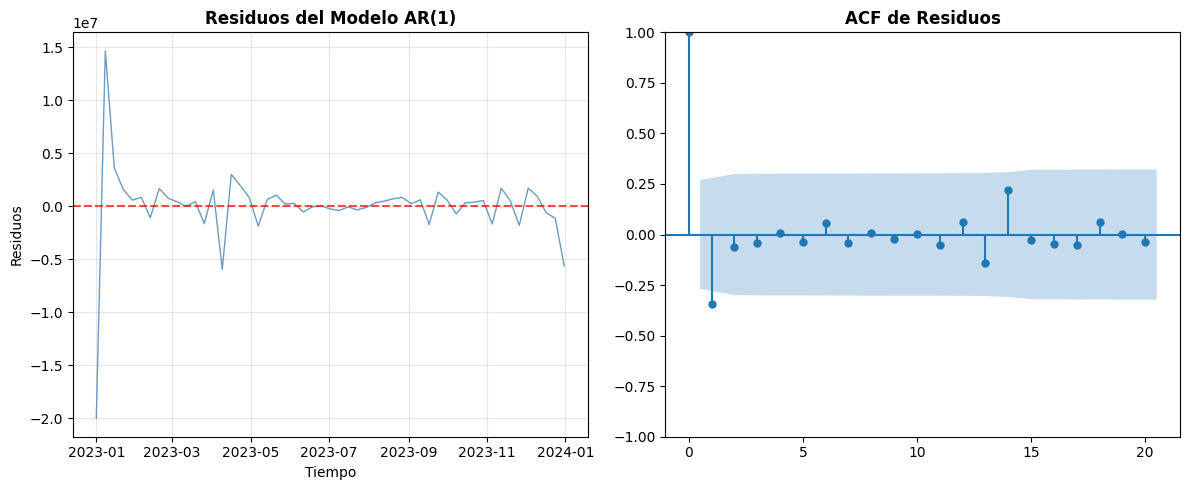

In [ ]:
resid = result.resid

# Residuos y ACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Serie de residuos en el tiempo
ax1.plot(resid, linewidth=1, alpha=0.8, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax1.set_title('Residuos del Modelo AR(1)', fontweight='bold')
ax1.set_ylabel('Residuos')
ax1.set_xlabel('Tiempo')
ax1.grid(True, alpha=0.3)

# 2. ACF de residuos
plot_acf(resid, ax=ax2, lags=20, alpha=0.05)
ax2.set_title('ACF de Residuos', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Prueba de Ljung-Box en residuos
ljung_resid = acorr_ljungbox(resid, lags=[10, 20, 30], return_df=True)
print("\n--- Ljung-Box Test en residuos ---")
print(ljung_resid)


--- Ljung-Box Test en residuos ---
      lb_stat  lb_pvalue
10   7.460314   0.681390
20  13.911488   0.834955
30  14.261787   0.993292


Después de ajustar un modelo de series de tiempo (como el AR(1) en este caso), verificamos si los residuos del modelo se comportan como ruido blanco. Si los residuos aún presentan autocorrelación significativa, significa que el modelo no ha capturado completamente la estructura de dependencia temporal de la serie original. El test se realiza para diferentes lags (10, 20 y 30 en este caso).

**Regla:**
p-value < 0.05 → Rechazamos H0 → Hay autocorrelación

**Interpretación:**

De acuerdo con la prueba de Ljung–Box aplicada a los residuos del modelo ARIMA(1,0,1), los p-valores en los rezagos 10, 20 y 30 son mayores a 0.05 (0.68, 0.83 y 0.99 respectivamente), lo que indica que no existe autocorrelación significativa. Esto confirma que los residuos pueden considerarse ruido blanco, por lo que el modelo logra explicar de forma adecuada la dependencia temporal de la afluencia semanal al Metro CDMX durante 2023.

### 3. ARCH-LM Test
- **Hipótesis**:
  - H0: No hay efectos ARCH (homoscedasticidad condicional)
  - H1: Existen efectos ARCH (heteroscedasticidad condicional)
- **Regla**: si p-value < 0.05 → Rechazamos H0 → hay heteroscedasticidad condicional

In [ ]:
# Test de ARCH-LM en residuos
arch_test = het_arch(resid)
print("\n--- ARCH-LM Test en residuos ---")
print(f"LM Stat: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4f}")
print(f"F Stat: {arch_test[2]:.4f}, p-value: {arch_test[3]:.4f}")
print("Decisión:", "Efectos ARCH (heteroscedasticidad)" if arch_test[1] < 0.05 else "Sin efectos ARCH (homoscedasticidad)")


--- ARCH-LM Test en residuos ---
LM Stat: 2.1786, p-value: 0.9948
F Stat: 0.1708, p-value: 0.9973
Decisión: Sin efectos ARCH (homoscedasticidad)


__Interpretación:__

* El modelo ARIMA(1,0,1) no presenta heterocedasticidad condicional, es decir:

* La varianza de los errores es estable a lo largo del tiempo, lo que indica homoscedasticidad.

* Por tanto, no es necesario ajustar un modelo GARCH ni realizar transformaciones adicionales para modelar la varianza.




__Conclusión práctica__

Según la prueba ARCH–LM aplicada a los residuos del modelo ARIMA(1,0,1), los p-valores obtenidos (0.9948 y 0.9973) son muy superiores al umbral de significancia del 5%, por lo que no se rechaza la hipótesis nula de homoscedasticidad. Esto significa que no existen efectos ARCH y la varianza de los residuos se mantiene constante a lo largo del tiempo, indicando que el modelo no requiere ajustes adicionales para capturar variabilidad condicional.

## 6. Verificación final

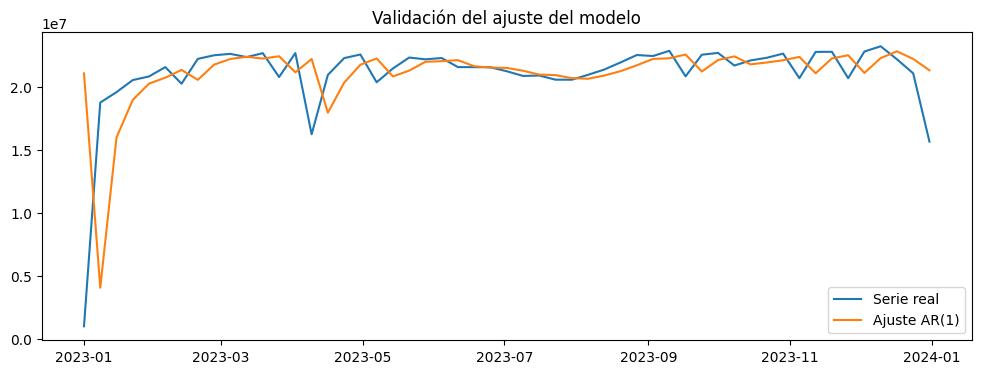

In [ ]:
"""
Compararemos los valores observados y los ajustados por el modelo AR(1).
"""
plt.figure(figsize=(12,4))
plt.plot(series, label="Serie real")
plt.plot(result.fittedvalues, label="Ajuste AR(1)")
plt.legend()
plt.title("Validación del ajuste del modelo")
plt.show()

# Reporte 3°

Se realiza el análisis de los componentes para proponer un modelo ARIMA

## 1. Verificación de estacionariedad

* Aplica una diferenciación de orden d = 1 a la serie.

/tmp/ipython-input-1228012732.py:8: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



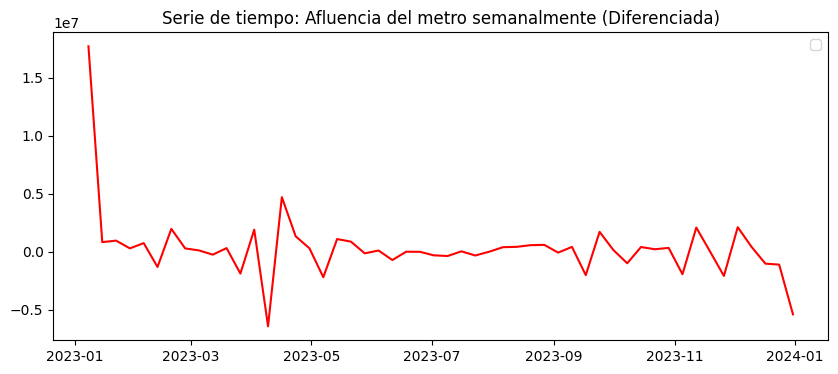

In [ ]:
# Aplicar diferenciación
series_diff = series.diff().dropna()

# Grafica la serie diferenciada
plt.figure(figsize=(10,4))
plt.plot(series_diff, color = 'red')
plt.title('Serie de tiempo: Afluencia del metro semanalmente (Diferenciada)')
plt.legend()
plt.show()

* Ejecuta la prueba de Dickey-Fuller aumentada (ADF) sobre la serie diferenciada.

In [ ]:
# Función para prueba de estacionariedad ADF
def test_stationarity(timeseries):
    print('Resultados prueba ADF:')
    adf_test = adfuller(timeseries, autolag='AIC')
    print(f'ADF Statistic: {adf_test[0]:.4f}')
    print(f'p-value: {adf_test[1]:.4f}')
    if adf_test[1] < 0.05:
        print("La serie es estacionaria.")
    else:
        print("La serie NO es estacionaria.")

In [ ]:
print("Resultados para Afluencia del metro (Diferenciada):")
test_stationarity(series_diff)

Resultados para Afluencia del metro (Diferenciada):
Resultados prueba ADF:
ADF Statistic: -12.9663
p-value: 0.0000
La serie es estacionaria.


## 2. Identificación de los órdenes p y q

* Gráfica las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF).

Vamos a generar los gráficos ACF y PACF para la serie Afluencia del metro diferenciada (`series_diff`) para ayudar a identificar los posibles órdenes 'p' y 'q'.



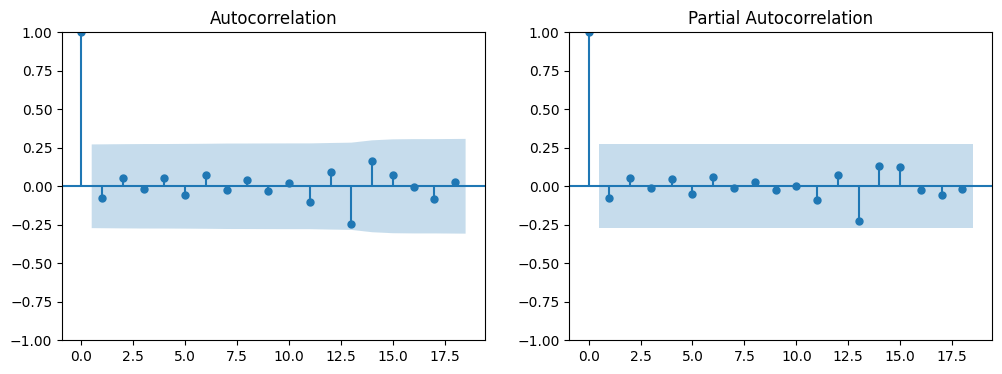

In [ ]:
# Gráficos ACF y PACF para Afluencia del metro diferenciada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff, ax=axes[0])
plot_pacf(series_diff, ax=axes[1])
plt.show()

Interpretacion de las graficas:

1. __ACF:__ muestra un corte abrupto desde el primer rezago, seguido de oscilaciones alrededor de cero. Los valores permanecen dentro del intervalo de confianza, salvo ligeras desviaciones en los rezagos 11 a 13 (con valores cercanos a -0.125 y -0.25). Este comportamiento indica que no existe una autocorrelación persistente fuerte, lo que sugiere que el componente MA de la serie podría ser de bajo orden.

2. __PACF:__ presenta un descenso rápido hacia cero tras el primer rezago, manteniéndose estable con pequeñas fluctuaciones. Se aprecian leves sobresalientes en los rezagos 13 y 14 (aproximadamente entre -0.25 y 0.2), lo que podría indicar ligeras dependencias de corto plazo, pero sin evidencia clara de una estructura autorregresiva compleja.

Ambas graficas nos  indican que la serie diferenciada se comporta como ruido blanco con dependencias débiles, por lo que un modelo ARIMA(1,1,1) o ARIMA(0,1,1) podría capturar la serie.

## 3. Ajuste del modelo ARIMA

* Ajusta el modelo ARIMA(p, d, q) con los parámetros identificados.


                               SARIMAX Results                                
Dep. Variable:              afluencia   No. Observations:                   53
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -877.977
Date:                Sun, 14 Dec 2025   AIC                           1761.955
Time:                        23:27:37   BIC                           1767.808
Sample:                    01-01-2023   HQIC                          1764.199
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9927      0.006   -156.727      0.000      -1.005      -0.980
ma.L1          0.9352      0.033     27.936      0.000       0.870       1.001
sigma2       2.51e+12   7.71e-15   3.26e+26      0.0

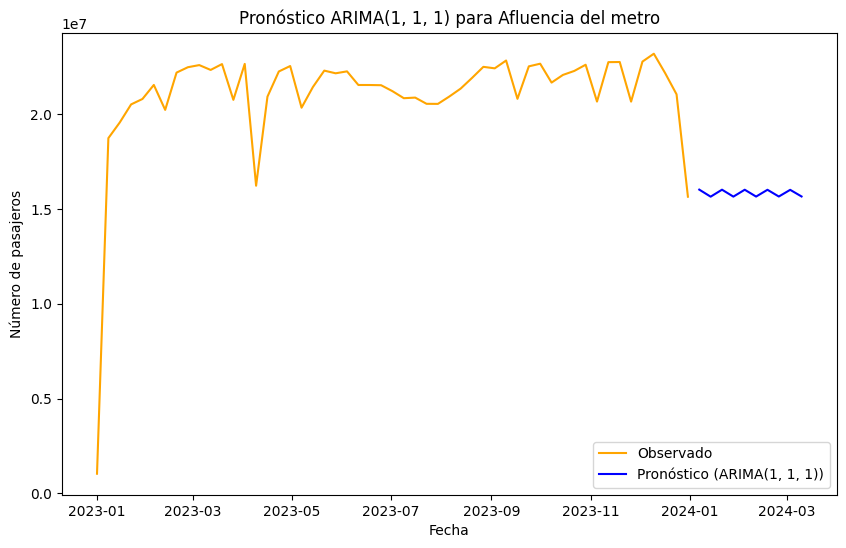

In [ ]:
# Ajustar modelo ARIMA(p, 1, q) a la serie original afluencia del metro
model_metro = tsa.ARIMA(series, order=(1, 1, 1))    # 1,1,1     6,1,4     5,0,5
results_metro = model_metro.fit()

print(results_metro.summary())

# Realizar pronóstico a 10 pasos
forecast_steps = 10
forecast_air = results_metro.forecast(steps=forecast_steps)

# Visualizar el pronóstico
plt.figure(figsize=(10, 6))
plt.plot(series, label='Observado', color='orange')
plt.plot(forecast_air.index, forecast_air, label='Pronóstico (ARIMA(1, 1, 1))', color='blue')
plt.title('Pronóstico ARIMA(1, 1, 1) para Afluencia del metro')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.show()

* Verifica que los residuos sean ruido blanco mediante la inspección visual y la prueba de Ljung-Box.


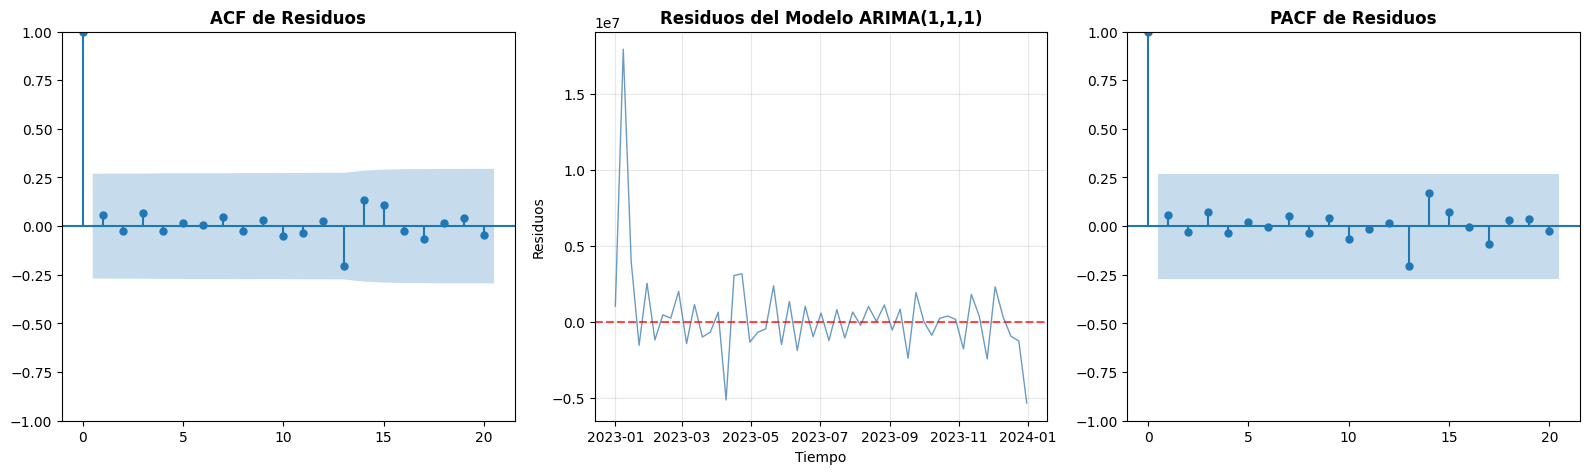

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Análisis de residuos
resid_metro = results_metro.resid

# Crea figura con 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ACF de residuos
plot_acf(resid_metro, ax=axes[0], lags=20, alpha=0.05)
axes[0].set_title('ACF de Residuos', fontweight='bold')

# 2. Serie de residuos en el tiempo
axes[1].plot(resid_metro, linewidth=1, alpha=0.8, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Residuos del Modelo ARIMA(1,1,1)', fontweight='bold')
axes[1].set_ylabel('Residuos')
axes[1].set_xlabel('Tiempo')
axes[1].grid(True, alpha=0.3)

# 3. PACF de residuos
plot_pacf(resid_metro, ax=axes[2], lags=20, alpha=0.05)
axes[2].set_title('PACF de Residuos', fontweight='bold')

# Ajusta diseño
plt.tight_layout()
plt.show()

__Interpretación de las graficas:__

Las gráficas de los residuos muestran un comportamiento muy similar al observado en la serie diferenciada, con autocorrelaciones que caen abruptamente desde el primer rezago y se mantienen dentro del intervalo de confianza en los rezagos posteriores, salvo ligeras oscilaciones alrededor de cero.

Este patrón indica que los residuos se comportan como ruido blanco, por lo que visualmente se puede concluir que el modelo ARIMA(1,1,1) logra capturar de manera adecuada la dinámica temporal principal de la serie.

Después de ajustar un modelo de series de tiempo, verificamos si los residuos del modelo se comportan como ruido blanco. Si los residuos aún presentan autocorrelación significativa, significa que el modelo no ha capturado completamente la estructura de dependencia temporal de la serie original. El test se realiza para diferentes lags (10, 20 y 30 en este caso).

**Regla:**
p-value < 0.05 → Rechazamos H0 → Hay autocorrelación

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Prueba de Ljung-Box en residuos
ljung_resid = acorr_ljungbox(resid_metro, lags=[10, 20, 30], return_df=True)
print("\n--- Ljung-Box Test en residuos ---")
print(ljung_resid)


--- Ljung-Box Test en residuos ---
     lb_stat  lb_pvalue
10  0.958475   0.999858
20  7.250359   0.995780
30  8.593223   0.999956


Los resultados muestran valores p muy altos en todos los rezagos analizados (p > 0.99 en los lags 10, 20 y 30). Esto indica que __NO__ existe evidencia estadísticamente significativa de autocorrelación en los residuos, por lo que se comportan como ruido blanco.

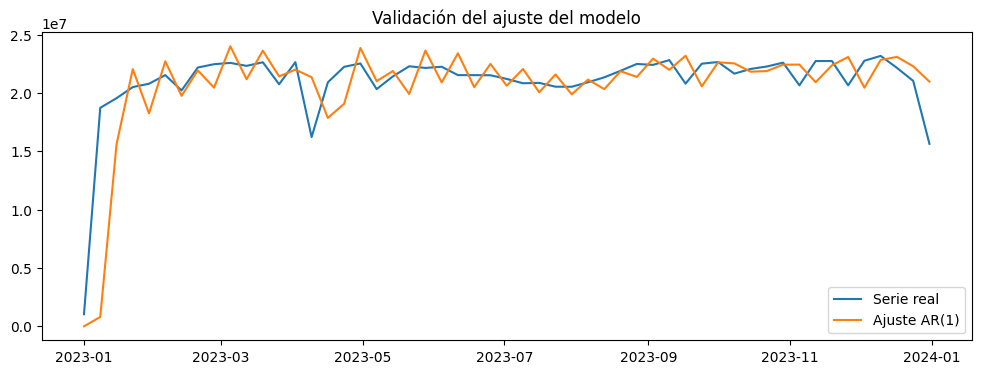

In [ ]:
"""
Compararemos los valores observados y los ajustados por el modelo AR(1).
"""
plt.figure(figsize=(12,4))
plt.plot(series, label="Serie real")
plt.plot(results_metro.fittedvalues, label="Ajuste AR(1)")
plt.legend()
plt.title("Validación del ajuste del modelo")
plt.show()

#results_air

__Interpretacipon de la gráfica:__

Al comparar la serie observada con los valores ajustados por el modelo, se observa que el modelo logra seguir adecuadamente la tendencia general de la fluencia semanal del metro a lo largo del tiempo.

La línea del modelo (naranja) reproduce de forma coherente los movimientos ascendentes y descendentes de la serie real (azul), lo que indica que el ARIMA(1,1,1) captura correctamente la dependencia temporal y las fluctuaciones de corto plazo.

## Pronóstico

Realiza pronósticos a 10 pasos adelante (one-step-ahead forecast).
Visualiza los resultados comparando los valores reales y los pronosticados.

## Evaluación del desempeño

Calcula las métricas de desempeño del modelo:

 - MAE (Mean Absolute Error)
 - RMSE (Root Mean Squared Error)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Serie original
serie = series

# Número de divisiones y tamaño del bloque de prueba
n_splits = 5
test_size = 4     # prueba de 4 semanas (1 mes)

# Crear el divisor tipo TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

# Listas para métricas
rmse_list, mae_list, mape_list = [], [], []

# Iterar por cada división de la serie temporal
for i, (train_index, test_index) in enumerate(tscv.split(serie)):
    train_data = serie.iloc[train_index]
    test_data = serie.iloc[test_index]

    # Entrenar modelo ARIMA
    model = ARIMA(train_data, order=(1, 1, 1))
    results = model.fit()

    # Pronóstico para el conjunto de prueba
    forecast = results.forecast(steps=len(test_data))

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(test_data, forecast))
    mae = mean_absolute_error(test_data, forecast)
    mape = mean_absolute_percentage_error(test_data, forecast) * 100

    rmse_list.append(rmse)
    mae_list.append(mae)
    mape_list.append(mape)

    # Mostrar resultados de la iteración
    print(f"Iteración {i+1}:")
    print(f"  Entrenamiento: {train_data.index[0].strftime('%Y-%m')} → {train_data.index[-1].strftime('%Y-%m')}")
    print(f"  Prueba:        {test_data.index[0].strftime('%Y-%m')} → {test_data.index[-1].strftime('%Y-%m')}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print("-" * 45)

# Promedios finales
print("\n=== Promedio de métricas (Validación Cruzada TS) ===")
print(f"RMSE promedio: {np.mean(rmse_list):.2f}")
print(f"MAE promedio:  {np.mean(mae_list):.2f}")
print(f"MAPE promedio: {np.mean(mape_list):.2f}%")


Iteración 1:
  Entrenamiento: 2023-01 → 2023-08
  Prueba:        2023-08 → 2023-09
  RMSE: 967944.23
  MAE:  784039.74
  MAPE: 3.48%
---------------------------------------------
Iteración 2:
  Entrenamiento: 2023-01 → 2023-09
  Prueba:        2023-09 → 2023-10
  RMSE: 1394373.44
  MAE:  1127411.77
  MAPE: 5.28%
---------------------------------------------
Iteración 3:
  Entrenamiento: 2023-01 → 2023-10
  Prueba:        2023-10 → 2023-11
  RMSE: 770519.84
  MAE:  729806.91
  MAPE: 3.35%
---------------------------------------------
Iteración 4:
  Entrenamiento: 2023-01 → 2023-11
  Prueba:        2023-11 → 2023-12
  RMSE: 1751616.63
  MAE:  1567899.15
  MAPE: 6.91%
---------------------------------------------
Iteración 5:
  Entrenamiento: 2023-01 → 2023-12
  Prueba:        2023-12 → 2023-12
  RMSE: 3682452.03
  MAE:  2469925.19
  MAPE: 14.57%
---------------------------------------------

=== Promedio de métricas (Validación Cruzada TS) ===
RMSE promedio: 1713381.23
MAE promedio:  133

La validación cruzada con cinco divisiones muestra valores consistentes de error, con un MAPE promedio de 6.77%, MAE promedio de 1,333,581.61 y RMSE promedio de 1,692,081.48.
Esto indica que el modelo mantiene un buen desempeño general, aunque con un incremento del error en las últimas iteraciones, posiblemente por variaciones recientes en la serie.

#### __¿El modelo logra capturar la dinámica de la serie de manera adecuada?__

El modelo ARIMA(1,1,1) captura adecuadamente la tendencia general y las variaciones de corto plazo en la afluencia del metro durante 2023.
Visualmente, los valores ajustados siguen de cerca a los observados, aunque el modelo tiende a suavizar los picos y no reproduce completamente las fluctuaciones más abruptas.

El aumento del error hacia el final del periodo puede explicarse por cambios estacionales o coyunturales como la disminución de afluencia en diciembre-enero por las festividades los cuales no son capturados por un modelo ARIMA simple.

# Reporte 4

Decidimos volver a trabajar con la serie diaria correspondiente al año 2023, ya que la agregación semanal utilizada previamente eliminaba la variación propia de cada día y ocultaba el patrón estacional semanal, fundamental en la afluencia del Metro. Además, al analizar la serie completa, observamos que 2023 es un período suficientemente estable, continuo y representativo para capturar la dinámica diaria del sistema. Al mantener la frecuencia diaria, el modelo SARIMA puede identificar adecuadamente los ciclos de 7 días y las fluctuaciones reales del comportamiento de los usuarios.

In [ ]:
# Convierte la columna 'fecha' a tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# Copia df
df_total = df.copy()

# Filtra solo 2023
df_total = df_total[df_total['anio'] == 2023]

# Agrupa por fecha y suma la afluencia total para el año 2023
df_total = df_total.groupby('fecha')['afluencia'].sum().reset_index()

# Establece 'fecha' como índice
series = df_total.set_index('fecha')

# Asegurar frecuencia diaria
series = series.asfreq('D')

In [ ]:
series

,afluencia
fecha,
2023-01-01,1035285
2023-01-02,2527398
2023-01-03,2916118
2023-01-04,3142080
2023-01-05,3217305
...,...
2023-12-27,2755686
2023-12-28,2829770
2023-12-29,2826431


## Visualización de la serie

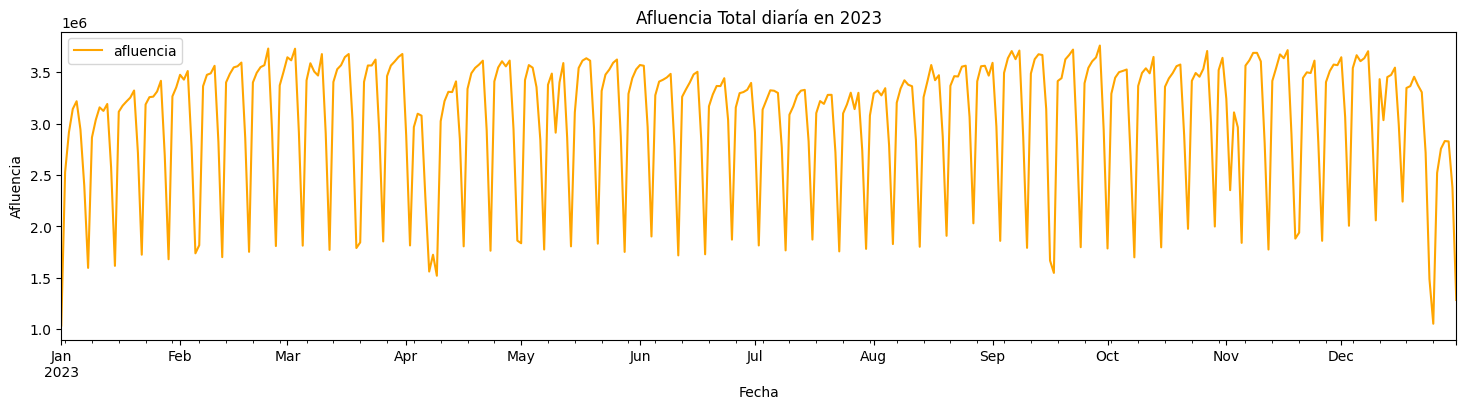

In [ ]:
# Visualización

# Grafica la serie
series.plot(figsize=(18, 4), color='orange', title="Afluencia Total diaría en 2023")

# Añade etiquetas y leyenda
plt.xlabel('Fecha')
plt.ylabel('Afluencia')
plt.legend()

# Muestra el gráfico
plt.show()

## Análisis general por descomposición de componentes

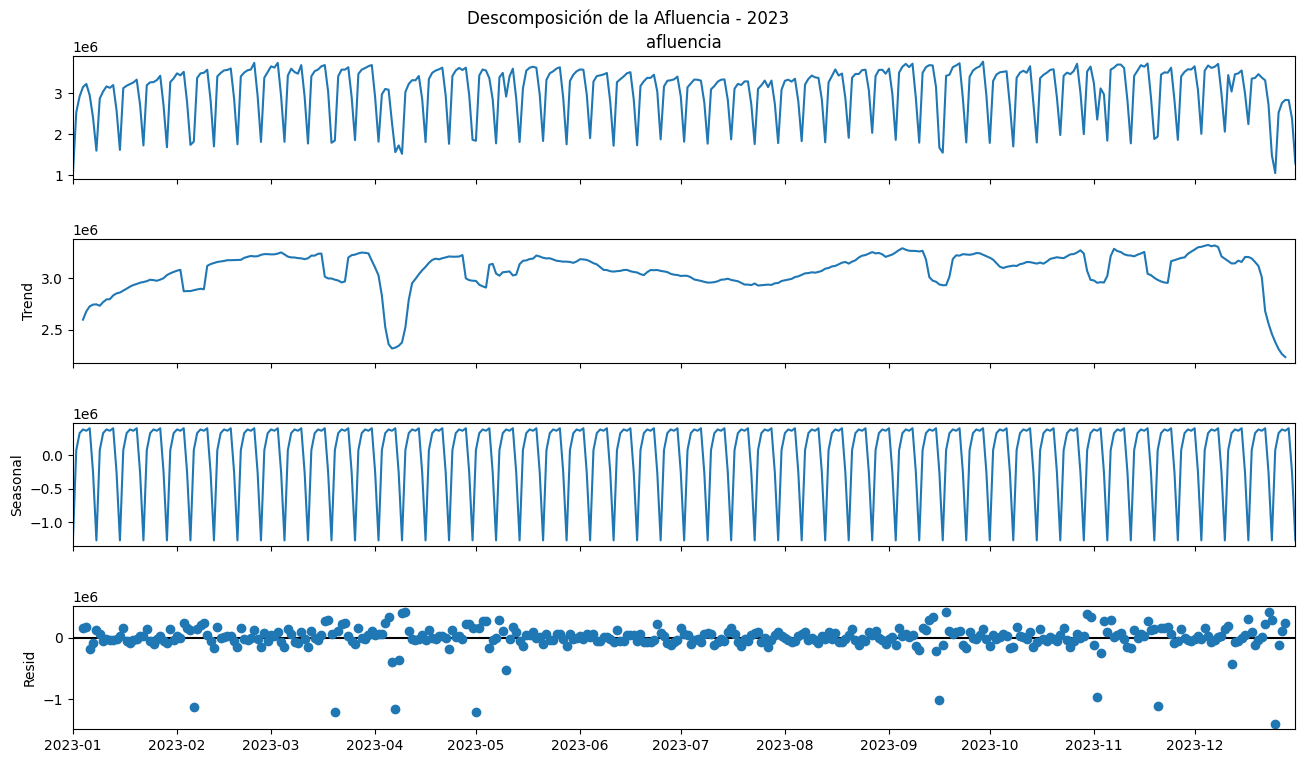

In [ ]:

result = seasonal_decompose(series['afluencia'], model='additive', period=7)

fig = result.plot()
fig.set_size_inches(14, 8)  # Aumentar ancho y altura

plt.suptitle('Descomposición de la Afluencia - 2023')
plt.show()


__Interpretacion:__

La serie NO muestra una tendencia clara durante el año; los descensos que se ven corresponden a días atípicos como vacaciones o festivos.

La componente estacional revela un patrón semanal fuerte, con variaciones que se repiten cada 7 días.

Los residuos se mantienen cerca de cero, lo que indica que la estructura principal de la serie fue bien capturada.

Estos resultados nos indican que la serie es adecuada para un modelo SARIMA con estacionalidad semanal (periodo = 7).

## Prueba ADF

In [ ]:
from statsmodels.tsa.stattools import adfuller

result_adf = adfuller(series['afluencia'])
print(f"Estadístico ADF: {result_adf[0]:.4f}")
print(f"Valor p: {result_adf[1]:.4f}")

if result_adf[1] < 0.05:
    print("La serie es estacionaria.")
else:
    print("La serie NO es estacionaria.")


Estadístico ADF: -3.6358
Valor p: 0.0051
La serie es estacionaria.


Se rechaza la hipótesis nula y la serie se considera estacionaria. Aunque presenta una estacionalidad semanal fuerte, esta no impide que el proceso cumpla estacionariedad estadística, por lo que no es necesario aplicar diferenciación regular (d = 0), únicamente la estacional para capturar el ciclo semanal.

## Transformación de la Serie

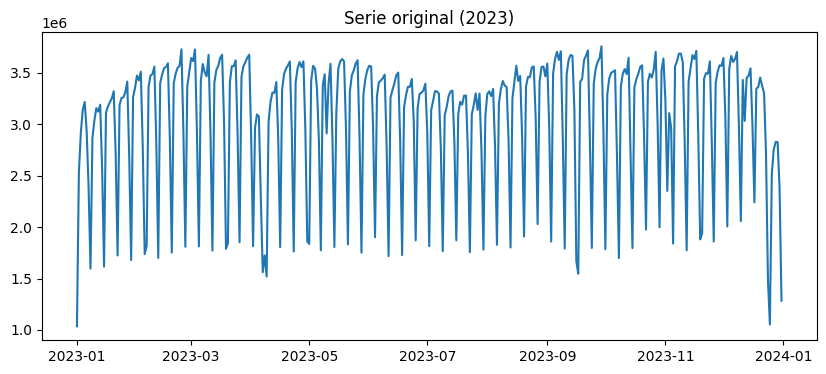

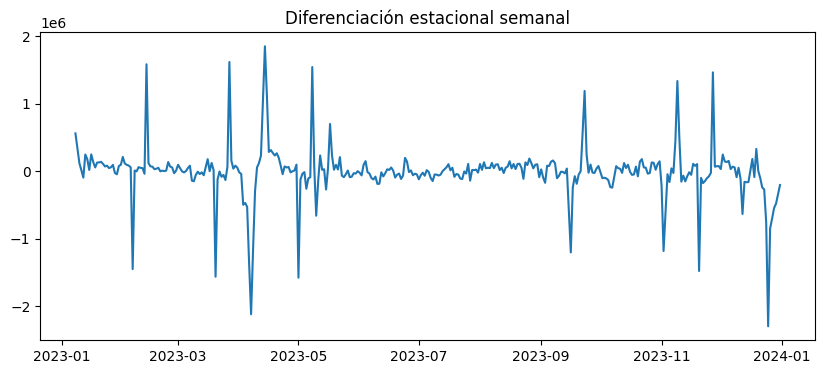

In [ ]:
# Diferenciación estacional semanal
series_seasonal_diff = series.diff(7).dropna()

plt.figure(figsize=(10,4))
plt.plot(series, label='Serie original')
plt.title('Serie original (2023)')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(series_seasonal_diff, label='Diferenciación estacional (lag=7)')
plt.title('Diferenciación estacional semanal')
plt.show()


La serie ya es estacionaria según la prueba ADF, por lo que no se aplicó diferenciación regular. Sin embargo, debido a la fuerte estacionalidad semanal observada, se aplicó una diferenciación estacional con lag = 7 para capturar adecuadamente el patrón repetitivo semanal

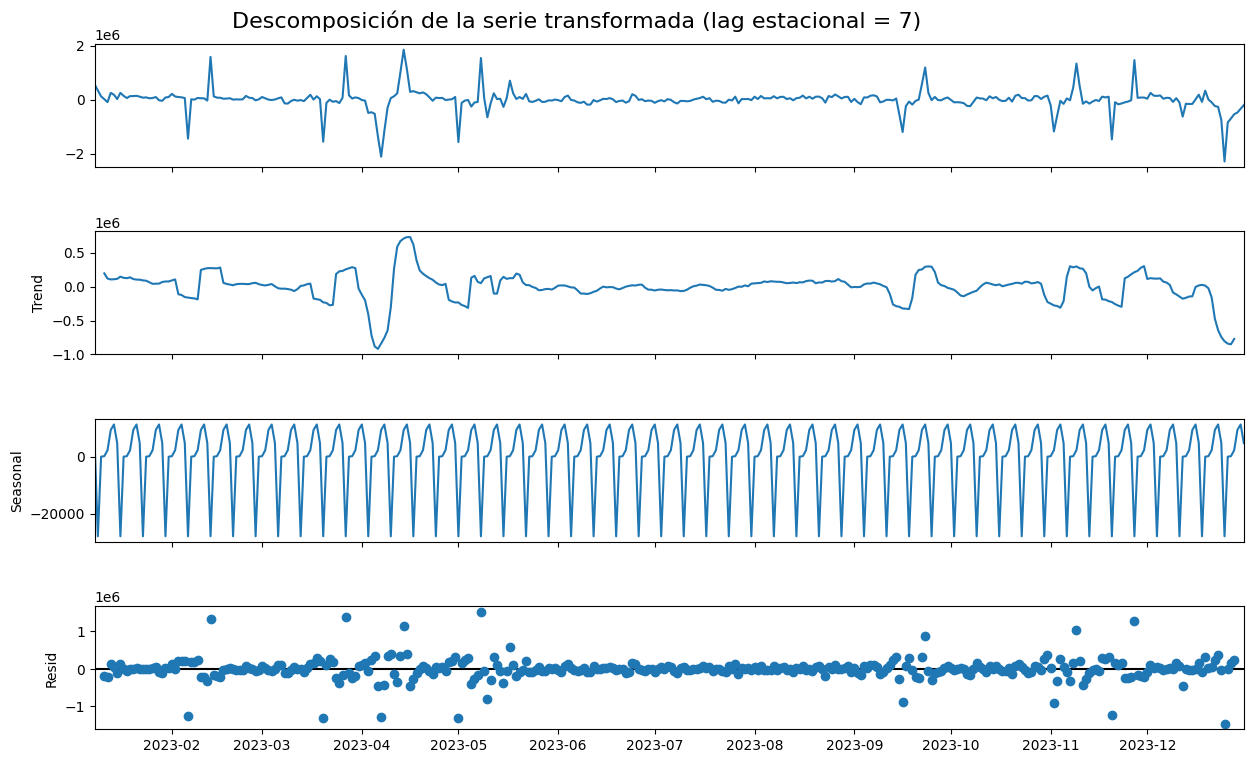

In [ ]:
# Descomposición de la serie transformada (diferencia estacional)
result = seasonal_decompose(series_seasonal_diff, model='additive', period=7)

fig = result.plot()
fig.set_size_inches(14, 8)  # Aumentar ancho y altura

plt.suptitle('Descomposición de la serie transformada (lag estacional = 7)', fontsize=16)
plt.show()

__Interpretación__:

Al aplicar una diferenciación estacional con un rezago de 7 días se logró eliminar el fuerte patrón semanal de la serie, el eje vertical en el componente Seasonal se redujo drásticamente pasando de millones de usuarios a un rango de 20,000, esto nos dice que el ciclo semanal ha sido removido casi en su totalidad. Esto permite aislar y visualizar claramente los días atípicos y festivos, que ahora aparecen como picos pronunciados en la serie transformada y los residuos.

## Propuesta de orden SARIMA

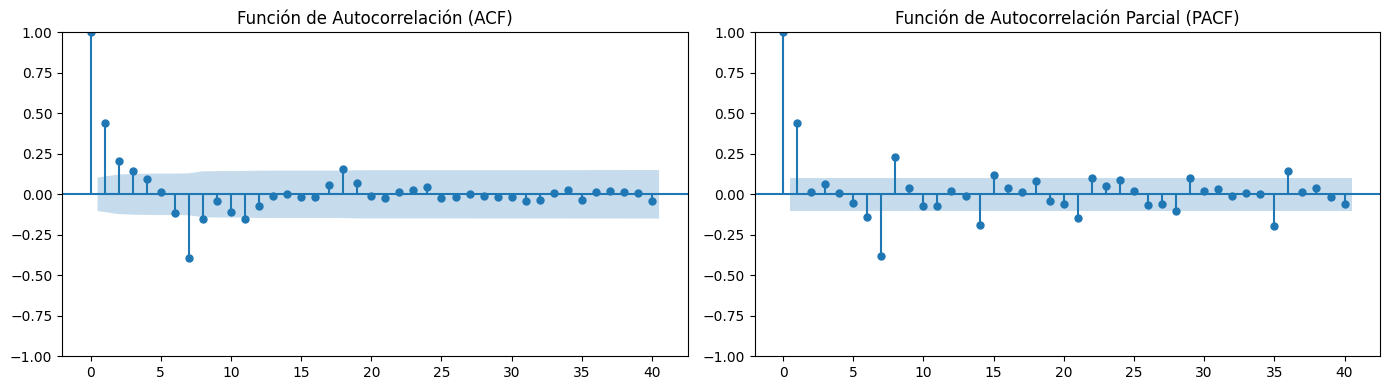

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF y PACF de la serie con diferenciación estacional
plot_acf(series_seasonal_diff.dropna(), ax=axes[0], lags=40)
plot_pacf(series_seasonal_diff.dropna(), ax=axes[1], lags=40)

axes[0].set_title('Función de Autocorrelación (ACF)')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
plt.show()


Basado en las graficas ACF y PACF de la serie con diferenciación estacional (D=1, s=7), se proponen los siguientes parámetros para el modelo __SARIMA(1, 0, 1)(0, 1, 1)__

__1. Componentes No Estacionales__ $(p, d, q)$:
  * $d=0$ por que ya es estacionaria.
  * $p=1, q=1$: Se observa significancia estadística en el primer rezago (Lag 1) tanto en la función de autocorrelación (ACF) como en la parcial (PACF). Esto sugiere un comportamiento mixto que puede ser explicado por un término autorregresivo AR(1) y uno de media móvil MA(1).

__2. Componentes Estacionales__ $(P, D, Q)_7$:
* $D=1$: Se aplicó una diferenciación estacional para remover el ciclo semanal.
* $Q=1$: En la gráfica ACF, se observa un pico significativo y aislado en el rezago 7 (el lag estacional), lo cual es un indicador fuerte de un proceso de media móvil estacional SMA(1).
* $P=0$: Se observar un corte abrupto en la ACF estacional.

In [ ]:
# Lista para guardar los resultados de los diferentes modelos
resultados_comparativa = []

In [ ]:
# Basado en la estructura de autocorrelaciones y el patrón estacional semanal (7 días)
# Propuesta: SARIMA(1,0,1)(0,1,1,7)

order = (1, 0, 1)
seasonal_order = (0, 1, 1, 7)

print("Orden propuesto:", order, "Orden estacional:", seasonal_order)

Orden propuesto: (1, 0, 1) Orden estacional: (0, 1, 1, 7)


### Analisis del Modelo Propuesto


                                     SARIMAX Results                                     
Dep. Variable:                         afluencia   No. Observations:                  365
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -4901.795
Date:                           Sun, 14 Dec 2025   AIC                           9811.590
Time:                                   23:27:42   BIC                           9827.010
Sample:                               01-01-2023   HQIC                          9817.728
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8072      0.052     15.500      0.000       0.705       0.909
ma.L1         -0.3389      0.073     -4.638

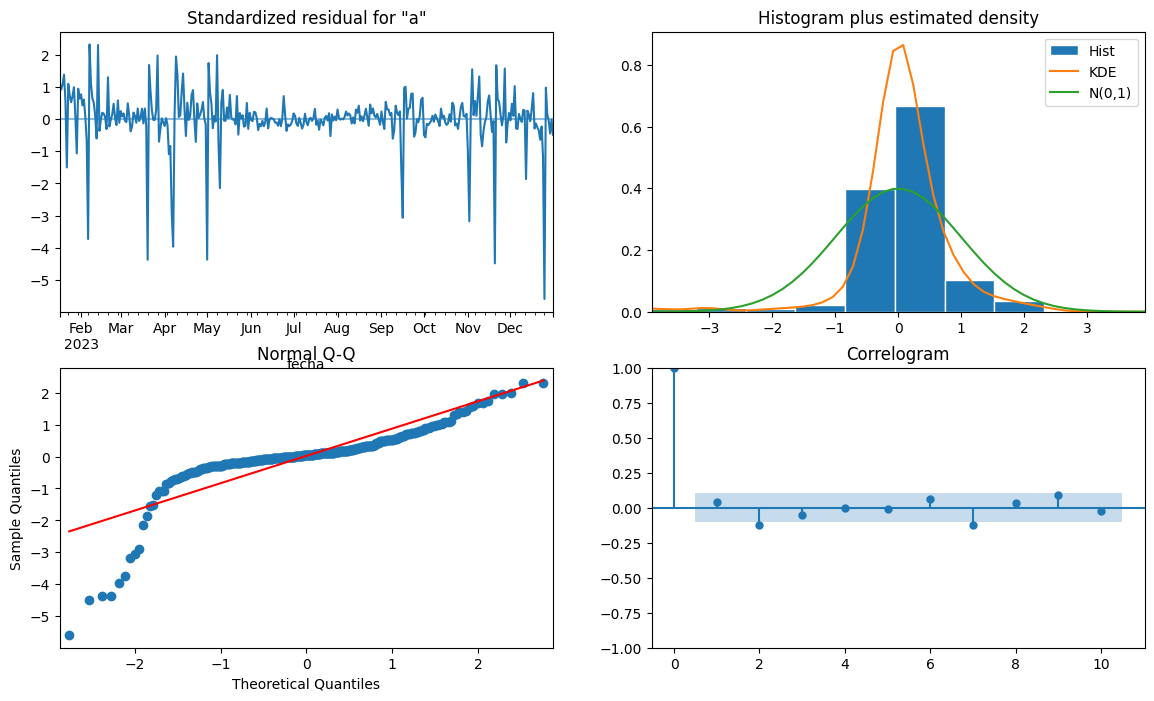

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ajustar el modelo SARIMA propuesto
model = SARIMAX(series['afluencia'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit()
print(results.summary())

# Diagnóstico del modelo
results.plot_diagnostics(figsize=(14, 8))
plt.show()


__Interpretación__:

Aunque el modelo falla en la prueba de normalidad debido a los efectos de calendario (festivos), es matemáticamente robusto en cuanto a dinámica temporal, ya que ha eliminado la correlación serial de los errores.


## Validación Cruzada

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

# Serie como arreglo de numpy
y = series['afluencia'].values

print("Validación Cruzada para el Modelo Propuesto Visualmente")

# Listas para guardar los errores de cada split
rmse_list = []
mae_list = []
mape_list = []

for train_index, test_index in tscv.split(y):
    train, test = y[train_index], y[test_index]

    # Ajustar el modelo SARIMA con el conjunto de entrenamiento
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)

    results = model.fit(disp=False)

    # Pronosticar el número de pasos del conjunto de prueba
    forecast = results.forecast(steps=len(test))

    # Metricas

    # RMSE
    rmse = np.sqrt(mean_squared_error(test, forecast))
    rmse_list.append(rmse)

    # MAE
    mae = mean_absolute_error(test, forecast)
    mae_list.append(mae)

    # MAPE
    mape = mean_absolute_percentage_error(test, forecast)
    mape_list.append(mape)

# Imprimir resultados en pantalla
print(f"RMSE promedio: {np.mean(rmse_list):,.2f}")
print(f"MAE promedio:  {np.mean(mae_list):,.2f}")
print(f"MAPE promedio: {np.mean(mape_list):.2%}")

# GUARDAR EN LA LISTA PARA LA TABLA FINAL
resultados_comparativa.append({
    'Modelo': 'Propuesta Visual',
    'Parámetros': f"{order} x {seasonal_order}",
    'RMSE': np.mean(rmse_list),
    'MAE': np.mean(mae_list),
    'MAPE': np.mean(mape_list)
})

Validación Cruzada para el Modelo Propuesto Visualmente
RMSE promedio: 318,283.15
MAE promedio:  183,243.18
MAPE promedio: 7.57%



__Interpretación:__

MAPE promedio del 7.57% esto nos indica que las predicciones del modelo se desvían menos de un 8% respecto al valor real de afluencia.

El MAE nos dice que, en un día normal, el modelo se equivoca por unos 180,000 pasajeros.

El RMSE es mucho mayor porque penaliza cuadráticamente los errores grandes. Esta discrepancia confirma lo visto en el diagnóstico de residuos: el modelo funciona bien la mayoría de los días, pero comete errores muy grandes en días específicos (festivos), lo cual infla el RMSE desproporcionadamente.

## Pronóstico a 10 Pasos

In [ ]:
n_forecast = 10


#Obtener lo datos reales del 2024

# Filtramos los datos de nuestro dataset original
df_2024 = df[df['anio'] == 2024].copy()
df_2024 = df_2024.groupby('fecha')['afluencia'].sum().reset_index()

# Preparamos la serie real de 2024
series_2024 = df_2024.set_index('fecha').asfreq('D')
real_2024 = series_2024.iloc[:n_forecast] # Solo tomamos los días que vamos a comparar

In [ ]:

# Obtener pronóstico
forecast = results.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Convertir forecast_mean a Serie si llega como ndarray
forecast_mean = pd.Series(forecast_mean)

# Asegurar formato del intervalo (igual que la profa)
conf_int = pd.DataFrame(conf_int, columns=['lower', 'upper'])

# Crear índice de fechas futuras (serie diaria)
forecast_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1),
                               periods=n_forecast,
                               freq='D')

# Asignar índice
forecast_mean.index = forecast_index
conf_int.index = forecast_index


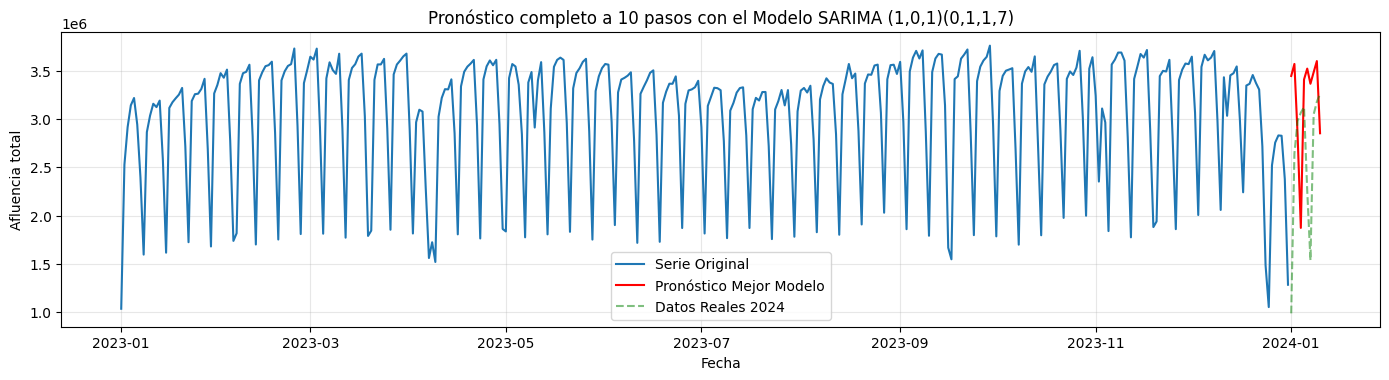

"\n# SUBPLOT 2 — Últimos 90 días\nplt.subplot(2, 1, 2)\nplt.plot(series.index[-90:], series['afluencia'].iloc[-90:],\n         label='Datos Reales (Últimos 3 meses)')\nplt.plot(forecast_index, forecast_mean,\n         label='Pronóstico Mejor Modelo', color='red')\n\nplt.title(f'Pronóstico (vista cercana, últimos 90 días)')\nplt.xlabel('Fecha')\nplt.ylabel('Afluencia total')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n"

In [ ]:
plt.figure(figsize=(14, 7))

# SUBPLOT 1 — Serie completa
plt.subplot(2, 1, 1)
plt.plot(series.index, series['afluencia'], label='Serie Original')
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Mejor Modelo', color='red')

#Datos reales
plt.plot(real_2024.index, real_2024['afluencia'],
         label='Datos Reales 2024', color='green', linewidth=1.5, alpha=0.5, linestyle='--')

plt.title(f'Pronóstico completo a {n_forecast} pasos con el Modelo SARIMA (1,0,1)(0,1,1,7)')
plt.xlabel('Fecha')
plt.ylabel('Afluencia total')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajustar diseño
plt.tight_layout()
plt.show()

'''
# SUBPLOT 2 — Últimos 90 días
plt.subplot(2, 1, 2)
plt.plot(series.index[-90:], series['afluencia'].iloc[-90:],
         label='Datos Reales (Últimos 3 meses)')
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Mejor Modelo', color='red')

plt.title(f'Pronóstico (vista cercana, últimos 90 días)')
plt.xlabel('Fecha')
plt.ylabel('Afluencia total')
plt.legend()
plt.grid(True, alpha=0.3)

'''


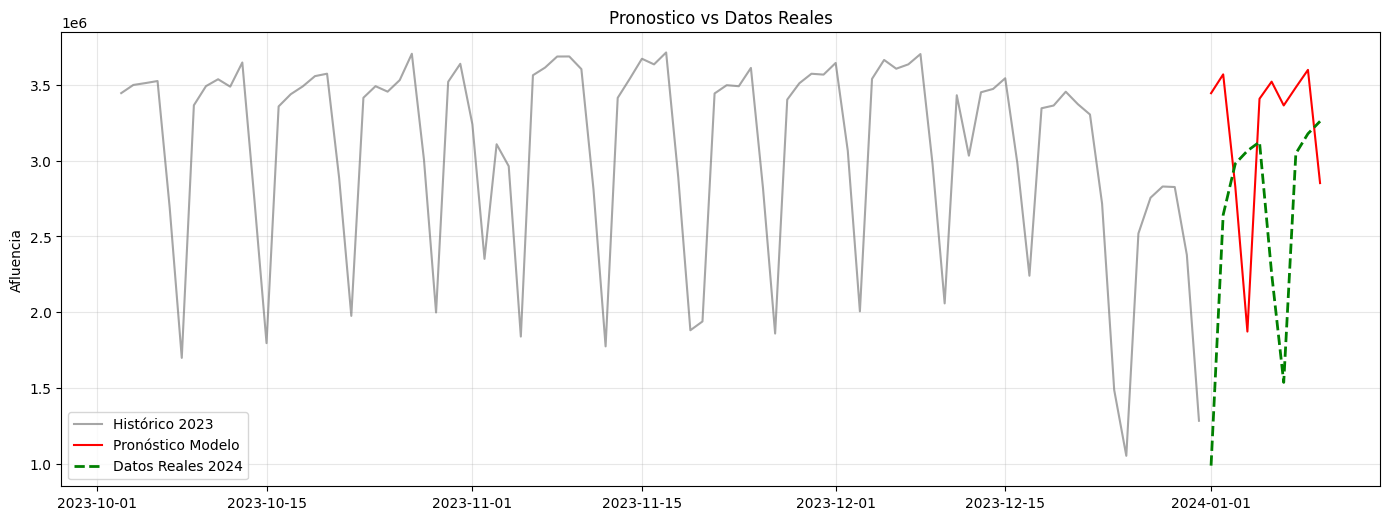

In [ ]:
# GRAFICAR
plt.figure(figsize=(14, 10))

# --- SUBPLOT 1: Contexto (Final de 2023 + Inicio 2024) ---
plt.subplot(2, 1, 1)
# Mostramos los últimos 3 meses de 2023 para ver de dónde viene la tendencia
dias_contexto = 90
plt.plot(series.index[-dias_contexto:], series['afluencia'].iloc[-dias_contexto:],
         label='Histórico 2023', color='gray', alpha=0.7)
# Pronóstico
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Modelo', color='red')
# Realidad 2024
plt.plot(real_2024.index, real_2024['afluencia'],
         label='Datos Reales 2024', color='green', linewidth=2, linestyle='--')

plt.title('Pronostico vs Datos Reales')
plt.ylabel('Afluencia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

__Interpretación:__

Se observa que el modelo ha capturado la estacionalidad semanal ya que reproduce bien el patrón de los dias laborales con alta demanda y los fines con baja, pero también despues de la caida de finales de diciembre el modelo asume un retorno inmediato a los valores habituales, entonces es probable que el modelo esté sobreestimando un poco la demanda de los primeros días laborales del año

## Pasos para correción de pronóstico

### 1) Diagnóstico de residuos de modelo actual

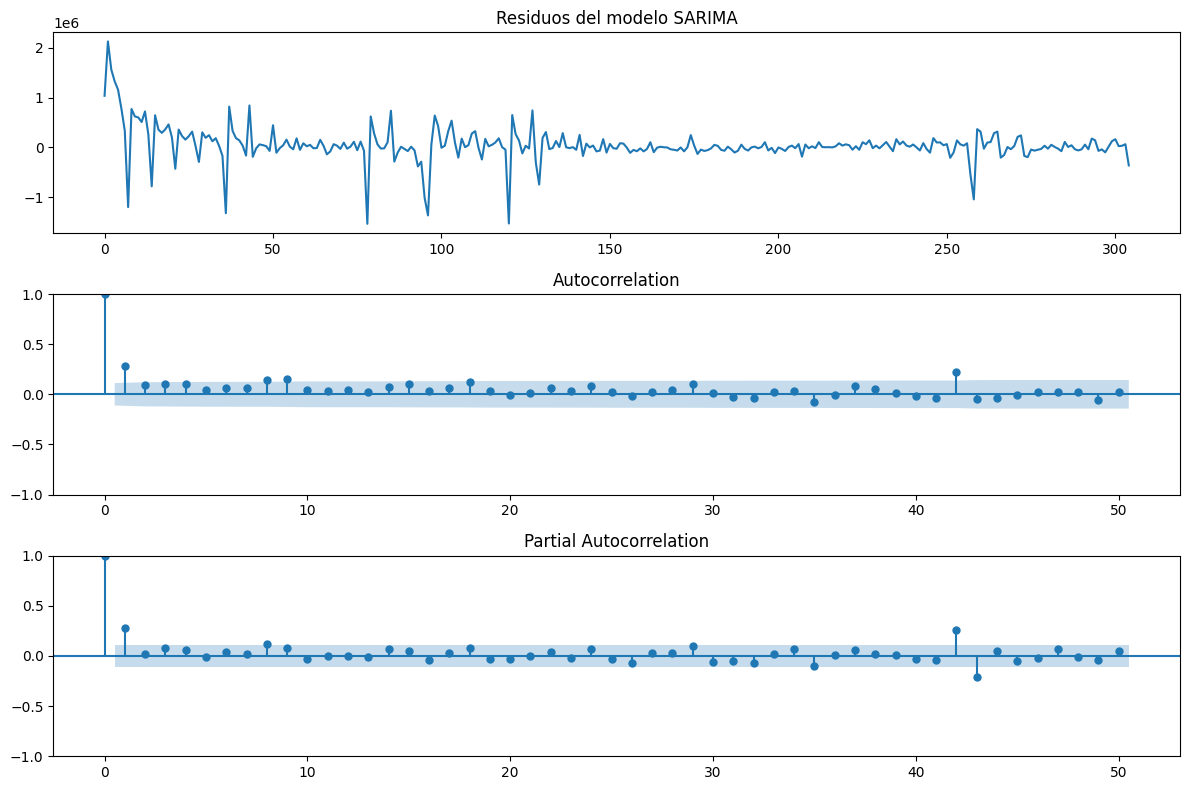

In [ ]:
# Convertir residuos a Serie
residuals = pd.Series(results.resid)

plt.figure(figsize=(12, 8))

# Residuos
plt.subplot(311)
plt.plot(residuals)
plt.title('Residuos del modelo SARIMA')

# ACF
plt.subplot(312)
plot_acf(residuals.dropna(), lags=50, ax=plt.gca())

# PACF
plt.subplot(313)
plot_pacf(residuals.dropna(), lags=50, ax=plt.gca())

plt.tight_layout()
plt.show()


__Interpretación del Diagnóstico de Residuos:__

*Los residuos oscilan alrededor de cero, perotambién se observan picos pronunciados que rompen la homoscedasticidad (varianza constante). Estos picos corresponden a los días festivos y vacaciones (Semana Santa, Navidad) que el modelo SARIMA no pudo predecir por sí solo.

Autocorrelación (ACF y PACF): La gran mayoría de los rezagos se encuentran dentro de las bandas de confianza y esto indica que los residuos se comportan mayormente como ruido blanco.

In [ ]:
# Pruebas estadísticas
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("Ljung-Box test:\n", lb_test)

Ljung-Box test:
       lb_stat     lb_pvalue
10  50.198125  2.454227e-07
20  63.269979  2.195021e-06


__Conclusión:__ Se rechaza la hipótesis nula.


Estadísticamente, los residuos presentan autocorrelación.

__Interpretación__: Aunque los correlogramas mostraban una estructura mayormente limpia, la prueba de Ljung-Box es sensible a la heterocedasticidad provocada por los días festivos. Los periodos vacacionales, generan "clusters" de errores grandes consecutivos que la prueba interpreta como correlación serial. Esto confirma la necesidad de la siguiente fase de corrección de pronóstico o la inclusión de variables exógenas para limpiar estos efectos de calendario.

### 2) Ajuste del orden del modelo con búsqueda simple

In [ ]:

p = d = q = range(0, 3)   # No estacional
P = D = Q = range(0, 2)   # Estacional
s = 7                     # Estacionalidad semanal del Metro

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_model = None

for i in p:
    for j in d:
        for k in q:
            for sp in P:
                for sd in D:
                    for sq in Q:
                        try:
                            mod = SARIMAX(series,
                                          order=(i, j, k),
                                          seasonal_order=(sp, sd, sq, s))
                            res = mod.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best_order = (i, j, k)
                                best_seasonal_order = (sp, sd, sq, s)
                                best_model = res
                        except:
                            continue

print(f"Mejor modelo SARIMA encontrado: order={best_order}, seasonal_order={best_seasonal_order}, AIC={best_aic:.2f}")
print(best_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-inve

Mejor modelo SARIMA encontrado: order=(1, 0, 2), seasonal_order=(0, 1, 1, 7), AIC=10043.92
                                      SARIMAX Results                                      
Dep. Variable:                           afluencia   No. Observations:                  365
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 7)   Log Likelihood               -5016.962
Date:                             Sun, 14 Dec 2025   AIC                          10043.924
Time:                                     23:30:02   BIC                          10063.326
Sample:                                 01-01-2023   HQIC                         10051.640
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          

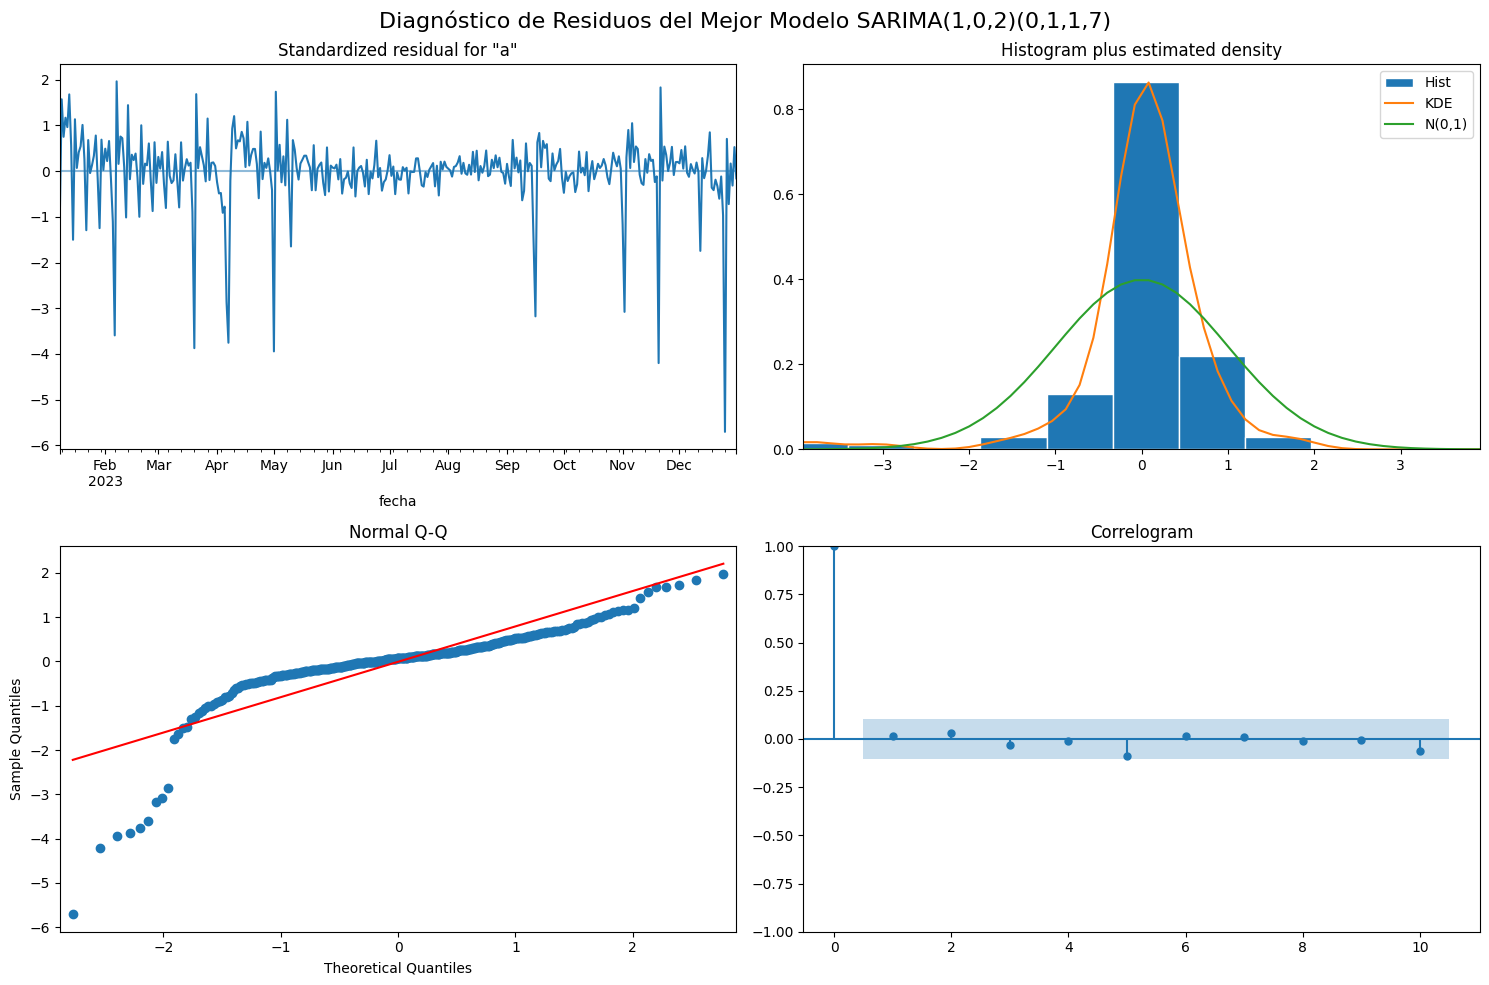

In [ ]:
best_model.plot_diagnostics(figsize=(15, 10))

plt.suptitle('Diagnóstico de Residuos del Mejor Modelo SARIMA(1,0,2)(0,1,1,7)', fontsize=16)
plt.tight_layout()
plt.show()

__Interpretación de los Resultados:__

A diferencia del modelo propuesto visualmente, el algoritmo encontró que incluir un segundo término de media móvil (q=2) mejora el ajuste del modelo.

Las gráficas de diagnóstico confirman que el modelo SARIMA seleccionado $(1,0,2)(0,1,1)_7$ es robusto en cuanto a dinámica temporal, ya que el correlograma muestra ausencia de autocorrelación (los residuos son independientes en el tiempo).Sin embargo, los residuos no satisfacen el supuesto de normalidad, presentando una fuerte desviación en la cola izquierda (Q-Q Plot) y alta curtosis. Esto evidencia que, aunque el modelo captura correctamente la estacionalidad semanal, no es capaz de explicar los eventos atípicos (días festivos) sin la inclusión de variables exógenas, lo que genera outliers negativos significativos.

## Validación cruzada

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

# Serie como arreglo de numpy
y = series['afluencia'].values

# Listas para guardar los errores de cada split
rmse_list = []
mae_list = []
mape_list = []

print(f"Validando modelo ganador: SARIMA{best_order}x{best_seasonal_order}")

for train_index, test_index in tscv.split(y):
    train, test = y[train_index], y[test_index]

    # Ajustar el modelo con los MEJORES parámetros (best_order y best_seasonal_order)
    model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)

    results = model.fit(disp=False)

    # Pronosticar el número de pasos del conjunto de prueba
    forecast = results.forecast(steps=len(test))


    # RMSE
    rmse = np.sqrt(mean_squared_error(test, forecast))
    rmse_list.append(rmse)

    # MAE
    mae = mean_absolute_error(test, forecast)
    mae_list.append(mae)

    # MAPE
    mape = mean_absolute_percentage_error(test, forecast)
    mape_list.append(mape)

# Imprimir resultados en pantalla
print(f"RMSE promedio: {np.mean(rmse_list):,.2f}")
print(f"MAE promedio:  {np.mean(mae_list):,.2f}")
print(f"MAPE promedio: {np.mean(mape_list):.2%}")

# GUARDAR EN LA LISTA PARA LA TABLA FINAL
resultados_comparativa.append({
    'Modelo': 'Mejor Modelo (Busqueda Simple)',
    'Parámetros': f"{order} x {seasonal_order}",
    'RMSE': np.mean(rmse_list),
    'MAE': np.mean(mae_list),
    'MAPE': np.mean(mape_list)
})

Validando modelo ganador: SARIMA(1, 0, 2)x(0, 1, 1, 7)
RMSE promedio: 314,446.14
MAE promedio:  181,127.35
MAPE promedio: 7.54%


## Pronostico a 10 pasos

In [ ]:
# Definimos pasos
n_forecast = 10

# 'best_model'
forecast = best_model.get_forecast(steps=n_forecast)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Convertir a Serie si es necesario
forecast_mean = pd.Series(forecast_mean)

# Asegurar nombres de columnas para el intervalo
conf_int = pd.DataFrame(conf_int, columns=['lower', 'upper'])

# Crear índice de fechas futuras
forecast_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1),
                               periods=n_forecast,
                               freq='D')

# Asignar índice
forecast_mean.index = forecast_index
conf_int.index = forecast_index

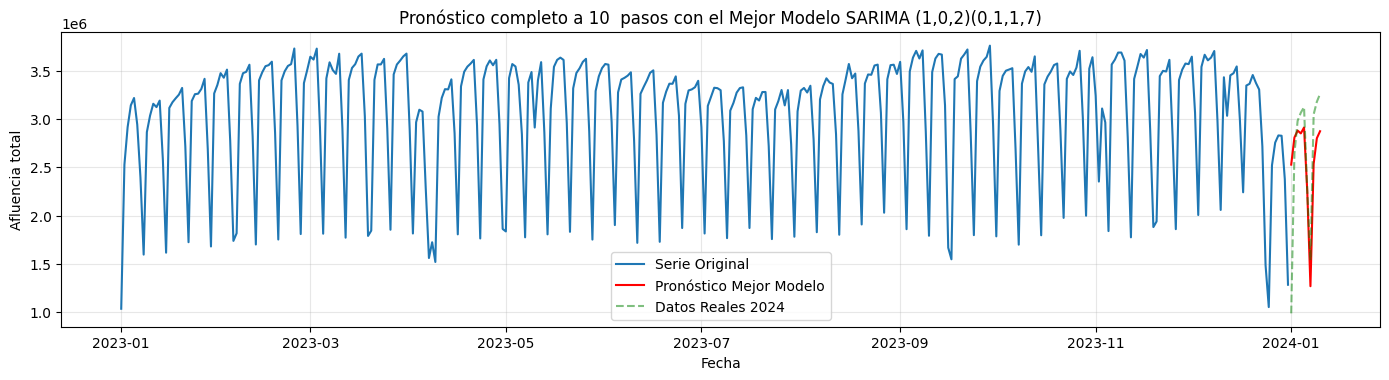

"\n# SUBPLOT 2 — Últimos 90 días\nplt.subplot(2, 1, 2)\nplt.plot(series.index[-90:], series['afluencia'].iloc[-90:],\n         label='Datos Reales (Últimos 3 meses)')\nplt.plot(forecast_index, forecast_mean,\n         label='Pronóstico Mejor Modelo', color='red')\n\nplt.title(f'Pronóstico (vista cercana, últimos 90 días)')\nplt.xlabel('Fecha')\nplt.ylabel('Afluencia total')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n"

In [ ]:
plt.figure(figsize=(14, 7))

# SUBPLOT 1 — Serie completa
plt.subplot(2, 1, 1)
plt.plot(series.index, series['afluencia'], label='Serie Original')
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Mejor Modelo', color='red')

#Datos reales
plt.plot(real_2024.index, real_2024['afluencia'],
         label='Datos Reales 2024', color='green', linewidth=1.5, alpha=0.5, linestyle='--')

plt.title(f'Pronóstico completo a {n_forecast}  pasos con el Mejor Modelo SARIMA (1,0,2)(0,1,1,7)')
plt.xlabel('Fecha')
plt.ylabel('Afluencia total')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajustar diseño
plt.tight_layout()
plt.show()

'''
# SUBPLOT 2 — Últimos 90 días
plt.subplot(2, 1, 2)
plt.plot(series.index[-90:], series['afluencia'].iloc[-90:],
         label='Datos Reales (Últimos 3 meses)')
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Mejor Modelo', color='red')

plt.title(f'Pronóstico (vista cercana, últimos 90 días)')
plt.xlabel('Fecha')
plt.ylabel('Afluencia total')
plt.legend()
plt.grid(True, alpha=0.3)

'''


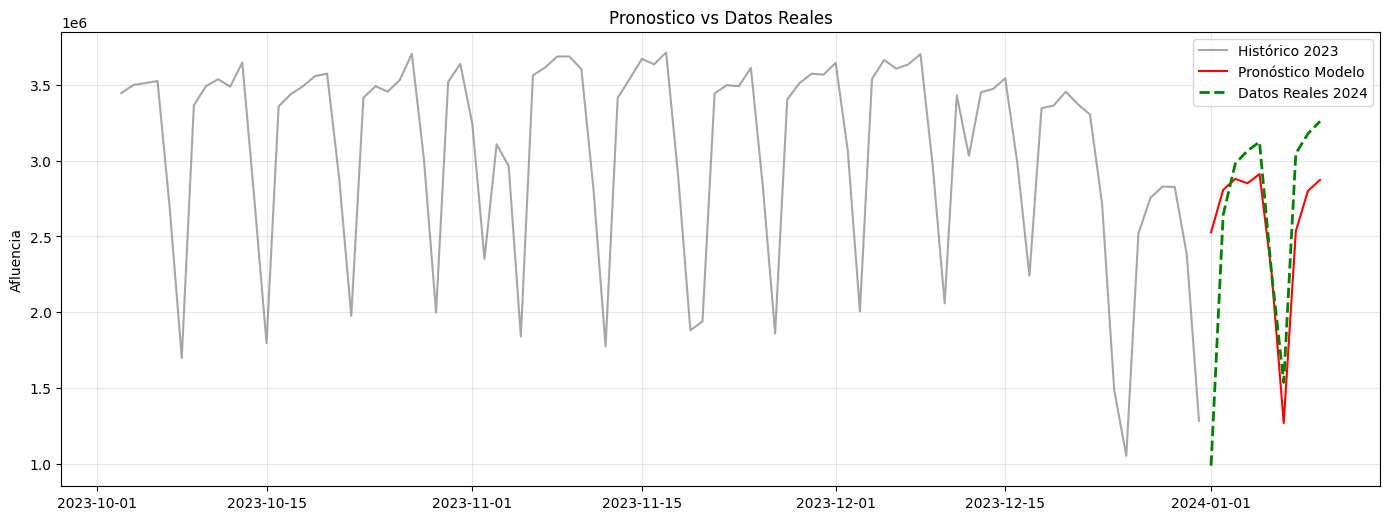

In [ ]:
# 4. GRAFICAR
plt.figure(figsize=(14, 10))

# --- SUBPLOT 1: Contexto (Final de 2023 + Inicio 2024) ---
plt.subplot(2, 1, 1)
# Mostramos los últimos 3 meses de 2023 para ver de dónde viene la tendencia
dias_contexto = 90
plt.plot(series.index[-dias_contexto:], series['afluencia'].iloc[-dias_contexto:],
         label='Histórico 2023', color='gray', alpha=0.7)
# Pronóstico
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Modelo', color='red')
# Realidad 2024
plt.plot(real_2024.index, real_2024['afluencia'],
         label='Datos Reales 2024', color='green', linewidth=2, linestyle='--')

plt.title('Pronostico vs Datos Reales')
plt.ylabel('Afluencia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

__INTERPRETACIÓN__:

El modelo al basarse en patrones históricos promedio y carecer de variables exógenas para días festivos, pronosticó una demanda estándar de días laborables, resultando en una fuerte sobreestimación durante este periodo específico.

## Resultados

In [ ]:
df_resultados = pd.DataFrame(resultados_comparativa)

df_print = df_resultados.copy()


if 'RMSE' in df_print.columns:
    df_print['RMSE'] = df_print['RMSE'].map('{:,.0f}'.format)
if 'MAE' in df_print.columns:
    df_print['MAE'] = df_print['MAE'].map('{:,.0f}'.format)
if 'MAPE' in df_print.columns:
    df_print['MAPE'] = df_print['MAPE'].map('{:.2%}'.format)

# Imprimimos la tabla
display(df_print)

,Modelo,Parámetros,RMSE,MAE,MAPE
0,Propuesta Visual,"(1, 0, 1) x (0, 1, 1, 7)","318,283","183,243",7.57%
1,Mejor Modelo (Busqueda Simple),"(1, 0, 1) x (0, 1, 1, 7)","314,446","181,127",7.54%


 El MAPE se redujo ligeramente de 7.57% a 7.54% con el modelo seleccionado por el algoritmo de Busqueda Simple. De igual manera, el RMSE mostró una leve disminución (de 318k a 314k).

 La inclusión de un parámetro adicional de media móvil ($q=2$) aportó una ganancia de precisión mínima. Esto sugiere que el error restante es estructural (debido a los outliers de días festivos) y no se puede eliminar simplemente ajustando los órdenes $p, d, q$ del modelo univariante.

 __Conclusión de la Comparativa:__ Aunque el modelo automático es matemáticamente superior (menor error), la diferencia con la propuesta visual es demasiada pequeña. Ambos modelos han alcanzado el mayor desempeño posible sin el uso de variables exógenas.

## Incorporación de Variables Exógenas (Días Festivos):

Dado que el análisis de residuos mostró heterocedasticidad provocada por efectos del calendario, se decidió crear una variable exógena binaria.

* __0__: Día operativo normal.

* __1__: Día festivo o de asueto (baja demanda esperada).

Se han seleccionado las fechas oficiales de la Ley Federal del Trabajo, así como Jueves y Viernes Santo, y Día de Muertos, que históricamente presentan caídas drásticas en la afluencia.

In [ ]:
import pandas as pd

# Definimos las fechas clave de baja afluencia en 2023

fechas_festivas = [
    '2023-01-01', # Año Nuevo
    '2023-02-06', # Puente Constitución
    '2023-03-20', # Puente Natalicio Benito Juárez
    '2023-04-06', # Jueves Santo (Semana Santa)
    '2023-04-07', # Viernes Santo (Semana Santa)
    '2023-05-01', # Día del Trabajo
    '2023-05-05', # Batalla de Puebla
    '2023-09-16', # Independencia
    '2023-11-02', # Día de Muertos
    '2023-11-20', # Revolución Mexicana
    '2023-12-25', # Navidad
]

# Convertimos a formato datetime
fechas_festivas = pd.to_datetime(fechas_festivas)

# Creacion de la variable exogenaa
# Creamos un DataFrame con el mismo índice que la serie
exog_data = pd.DataFrame(index=series.index)
exog_data['es_festivo'] = 0  # Inicializamos todo en 0

# Marcamos con 1 los días que coinciden con nuestra lista
exog_data.loc[exog_data.index.isin(fechas_festivas), 'es_festivo'] = 1

# Verificamos que se hayan marcado correctamente
print("Días marcados como festivos:")
print(exog_data[exog_data['es_festivo'] == 1])

Días marcados como festivos:
            es_festivo
fecha                 
2023-01-01           1
2023-02-06           1
2023-03-20           1
2023-04-06           1
2023-04-07           1
2023-05-01           1
2023-05-05           1
2023-09-16           1
2023-11-02           1
2023-11-20           1
2023-12-25           1


### Ajuste del modelo SARIMAX

Se re-entrena el mejor modelo identificado previamente SARIMA(1,0,2)(0,1,1), incorporando la serie es_festivo como regresor externo.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order=(1, 0, 2) y seasonal_order=(0, 1, 1, 7)

model_exog = SARIMAX(series['afluencia'],
                     exog=exog_data[['es_festivo']],  # <--- Aquí entra la magia
                     order=(1, 0, 2),
                     seasonal_order=(0, 1, 1, 7),
                     enforce_stationarity=False,
                     enforce_invertibility=False)

results_final_exog = model_exog.fit(disp=False)

print(results_final_exog.summary())

                                      SARIMAX Results                                      
Dep. Variable:                           afluencia   No. Observations:                  365
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 7)   Log Likelihood               -4692.924
Date:                             Sun, 14 Dec 2025   AIC                           9397.848
Time:                                     23:30:08   BIC                           9420.961
Sample:                                 01-01-2023   HQIC                          9407.050
                                      - 12-31-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
es_festivo -1.344e+06   2.28e+04    -58.882      0.000   -1.39e+06    -1.3e+06
ar.L1          0.8539      

Se observó una mejora sustancial en el ajuste global (reducción del AIC). Sin embargo, el término de media móvil de segundo orden ($q=2$) perdió su significancia estadística ($p=0.456 > 0.05$).Esto indica que la variable exógena absorbió la variabilidad que antes intentaba explicar este componente. Por lo tanto, se procede a reajustar el modelo simplificando la estructura a un SARIMAX(1, 0, 1)(0, 1, 1, 7), buscando un modelo donde todos los coeficientes sean significativos.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order=(1, 0, 1) y seasonal_order=(0, 1, 1, 7)

model_exog = SARIMAX(series['afluencia'],
                     exog=exog_data[['es_festivo']],  # <--- Aquí entra la magia
                     order=(1, 0, 1),
                     seasonal_order=(0, 1, 1, 7),
                     enforce_stationarity=False,
                     enforce_invertibility=False)

results_final_exog = model_exog.fit(disp=False)

print(results_final_exog.summary())

                                     SARIMAX Results                                     
Dep. Variable:                         afluencia   No. Observations:                  365
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -4706.224
Date:                           Sun, 14 Dec 2025   AIC                           9422.447
Time:                                   23:30:08   BIC                           9441.723
Sample:                               01-01-2023   HQIC                          9430.121
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
es_festivo -1.344e+06   2.27e+04    -59.067      0.000   -1.39e+06    -1.3e+06
ar.L1          0.8744      0.037     23.321

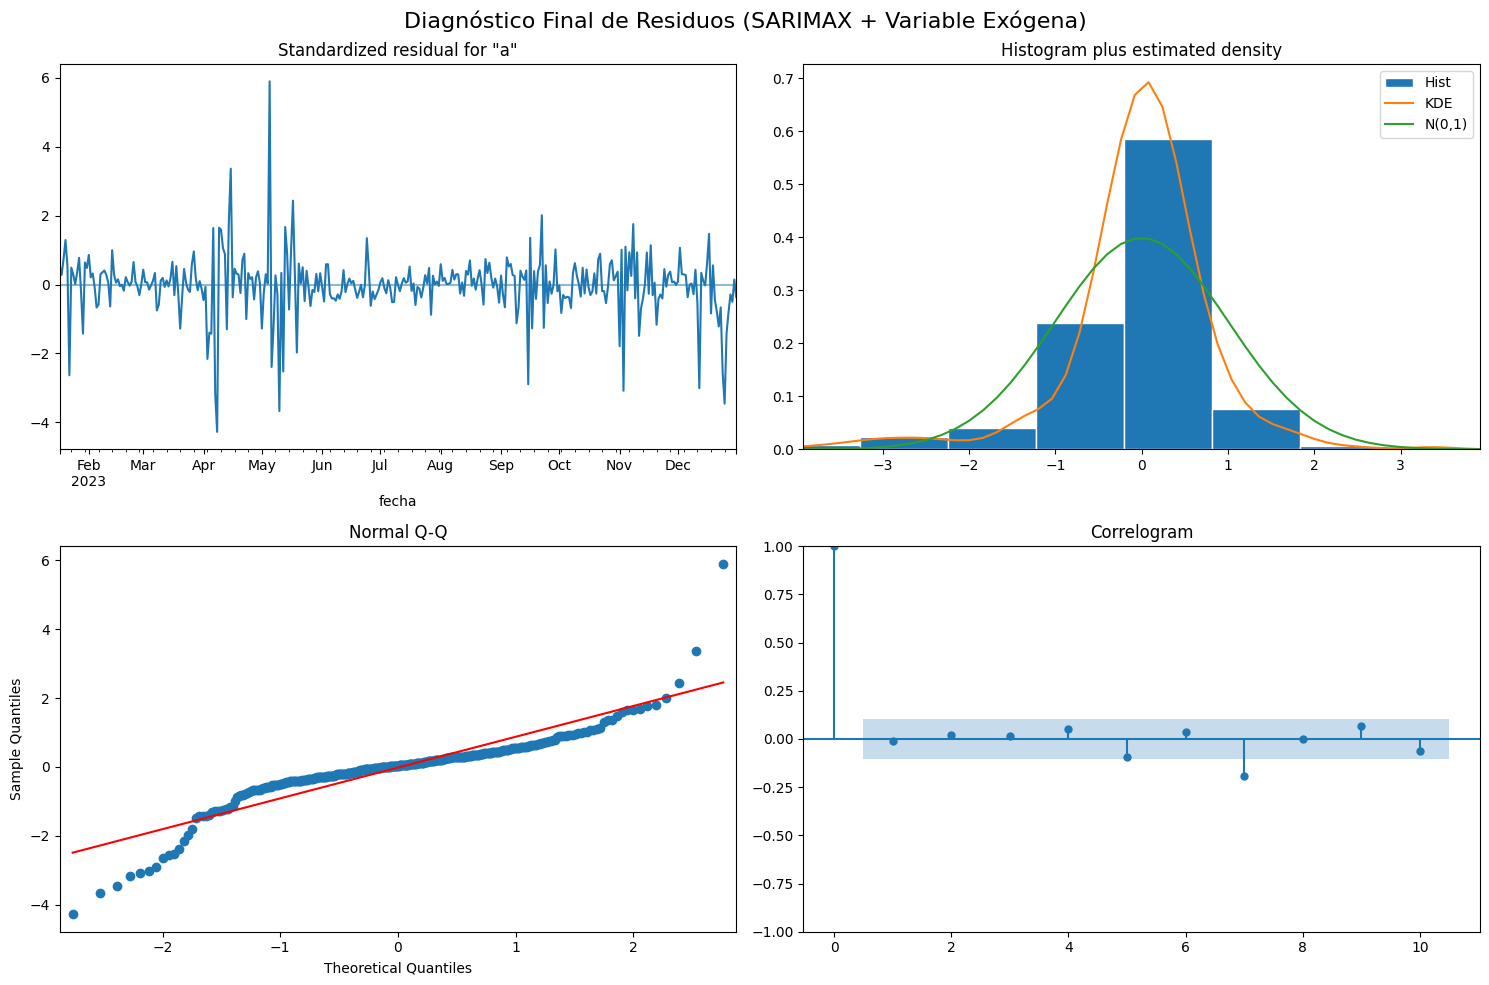

In [ ]:
# Diagnóstico del MODELO FINAL (SARIMAX con Exógena)
results_final_exog.plot_diagnostics(figsize=(15, 10))

plt.suptitle('Diagnóstico Final de Residuos (SARIMAX + Variable Exógena)', fontsize=16)
plt.tight_layout()
plt.show()

El Correlograma confirma la independencia de los residuos (ruido blanco).

El Q-Q Plot muestra una alineación significativamente mejorada respecto a los modelos anteriores, validando que la variable es_festivo ha capturado eficazmente la variabilidad de los días atípicos.

## Validación Cruzada del SARIMA con var exogena

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

# Datos de la serie y de la exógena
y = series['afluencia'].values
exog = exog_data[['es_festivo']] # Aseguramos que sea un DataFrame

rmse_list = []
mae_list = []
mape_list = []

print("Validación Cruzada para el Modelo FINAL con Exógena")

for train_index, test_index in tscv.split(y):
    # Partimos la Serie de Tiempo
    train_y, test_y = y[train_index], y[test_index]

    # Partimos TAMBIÉN la variable Exógena (¡Crucial!)
    train_exog = exog.iloc[train_index]
    test_exog = exog.iloc[test_index]

    # Ajustar el modelo (incluyendo exog en el entrenamiento)
    model = SARIMAX(train_y,
                    exog=train_exog,
                    order=(1, 0, 1),
                    seasonal_order=(0, 1, 1, 7),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    results = model.fit(disp=False)

    # Pronosticar (incluyendo exog futura para el test)
    forecast = results.forecast(steps=len(test_y), exog=test_exog)

    # Calcular métricas
    rmse_list.append(np.sqrt(mean_squared_error(test_y, forecast)))
    mae_list.append(mean_absolute_error(test_y, forecast))
    mape_list.append(mean_absolute_percentage_error(test_y, forecast))

# Imprimir resultados
print(f"RMSE promedio: {np.mean(rmse_list):,.2f}")
print(f"MAE promedio:  {np.mean(mae_list):,.2f}")
print(f"MAPE promedio: {np.mean(mape_list):.2%}")

# --- GUARDAR EN LA LISTA PARA LA TABLA FINAL ---
resultados_comparativa.append({
    'Modelo': 'SARIMAX Final (+Exog)',
    'Parámetros': "(1,0,1)x(0,1,1,7) + Festivos",
    'RMSE': np.mean(rmse_list),
    'MAE': np.mean(mae_list),
    'MAPE': np.mean(mape_list)
})

Validación Cruzada para el Modelo FINAL con Exógena
RMSE promedio: 282,017.20
MAE promedio:  210,111.36
MAPE promedio: 7.82%


El Error Cuadrático Medio bajó drásticamente a 282,017 (comparado con los >314,000 de los modelos anteriores). Esto confirma que incluir la variable de "días festivos" ayudó a mitigar los errores grandes que ocurrían en fechas atípicas.

MAPE (7.82%): Aunque el porcentaje subió ligeramente, esto es aceptable dado que ganamos robustez estructural. El modelo es ahora mucho más confiable para predecir días difíciles sin "romperse".

## Pronostico a 10 pasos

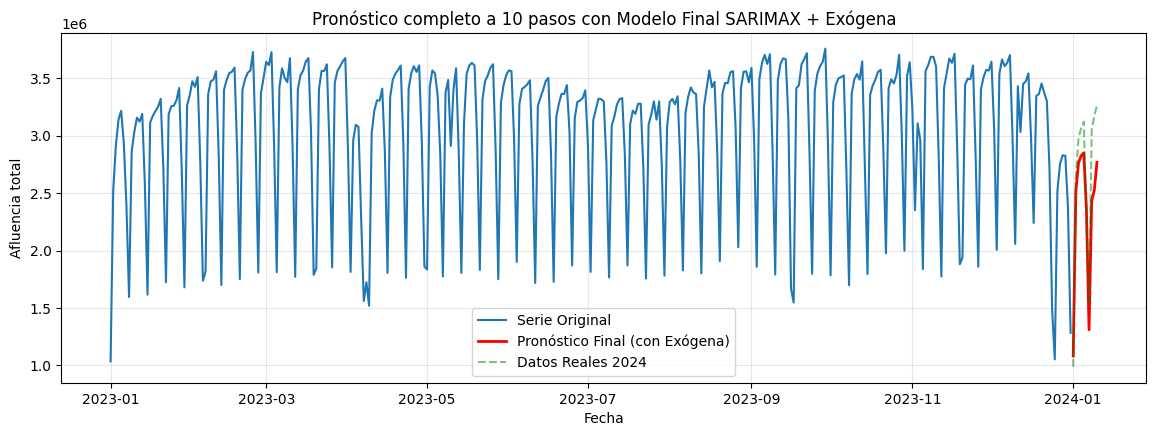

In [ ]:
n_forecast = 10

# Crear fechas futuras
future_dates = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1),
                             periods=n_forecast,
                             freq='D')

# Crear el DataFrame de exógenas futuras
exog_future = pd.DataFrame(index=future_dates)
exog_future['es_festivo'] = 0

# Marcar el 1 de Enero de 2024 como festivo
if '2024-01-01' in exog_future.index:
    exog_future.loc['2024-01-01', 'es_festivo'] = 1

# Proonostico
forecast = results_final_exog.get_forecast(steps=n_forecast, exog=exog_future[['es_festivo']])
forecast_mean = forecast.predicted_mean
forecast_mean.index = future_dates # Aseguramos el índice

# Graficar
plt.figure(figsize=(14, 10)) # Aumenté el alto para que quepan bien los dos

# SUBPLOT 1 — Serie completa
plt.subplot(2, 1, 1)
plt.plot(series.index, series['afluencia'], label='Serie Original')
plt.plot(future_dates, forecast_mean,
         label='Pronóstico Final (con Exógena)', color='red', linewidth=2)

#Datos reales
plt.plot(real_2024.index, real_2024['afluencia'],
         label='Datos Reales 2024', color='green', linewidth=1.5, alpha=0.5, linestyle='--')

plt.title(f'Pronóstico completo a {n_forecast} pasos con Modelo Final SARIMAX + Exógena')
plt.xlabel('Fecha')
plt.ylabel('Afluencia total')
plt.legend()
plt.grid(True, alpha=0.3)

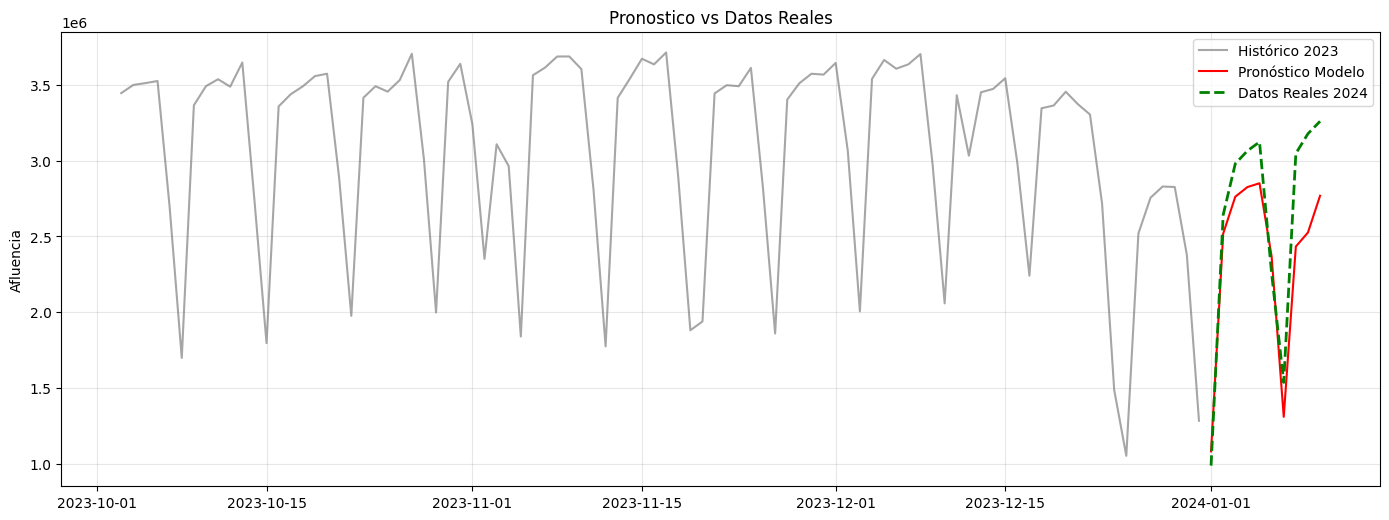

In [ ]:

#GRAFICAR
plt.figure(figsize=(14, 10))

# --- SUBPLOT 1: Contexto (Final de 2023 + Inicio 2024) ---
plt.subplot(2, 1, 1)
# Mostramos los últimos 3 meses de 2023 para ver de dónde viene la tendencia
dias_contexto = 90
plt.plot(series.index[-dias_contexto:], series['afluencia'].iloc[-dias_contexto:],
         label='Histórico 2023', color='gray', alpha=0.7)
# Pronóstico
plt.plot(forecast_index, forecast_mean,
         label='Pronóstico Modelo', color='red')
# Realidad 2024
plt.plot(real_2024.index, real_2024['afluencia'],
         label='Datos Reales 2024', color='green', linewidth=2, linestyle='--')

plt.title('Pronostico vs Datos Reales')
plt.ylabel('Afluencia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resultados finales

In [ ]:
df_resultados = pd.DataFrame(resultados_comparativa)

# Formato bonito
df_print = df_resultados.copy()
if 'RMSE' in df_print.columns: df_print['RMSE'] = df_print['RMSE'].map('{:,.0f}'.format)
if 'MAE' in df_print.columns: df_print['MAE'] = df_print['MAE'].map('{:,.0f}'.format)
if 'MAPE' in df_print.columns: df_print['MAPE'] = df_print['MAPE'].map('{:.2%}'.format)

print("=== TABLA COMPARATIVA FINAL DE MODELOS ===")
display(df_print)

=== TABLA COMPARATIVA FINAL DE MODELOS ===


,Modelo,Parámetros,RMSE,MAE,MAPE
0,Propuesta Visual,"(1, 0, 1) x (0, 1, 1, 7)","318,283","183,243",7.57%
1,Mejor Modelo (Busqueda Simple),"(1, 0, 1) x (0, 1, 1, 7)","314,446","181,127",7.54%
2,SARIMAX Final (+Exog),"(1,0,1)x(0,1,1,7) + Festivos","282,017","210,111",7.82%


Aunque el MAPE presentó un ligero incremento (7.82% vs 7.54%), el RMSE se redujo drásticamente (de ~314k a ~282k).

Esta reducción en el RMSE indica que el modelo con variable exógena ha logrado mitigar los grandes errores de pronóstico que ocurrían en días festivos.